### Import libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
from transformers import pipeline
from dotenv import load_dotenv
from datetime import datetime, timezone
from dateutil.relativedelta import relativedelta
import glob
import re
import sys
from langdetect import detect, DetectorFactory

/Users/lucas/Projects/ai-bubble/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load API config

In [2]:
load_dotenv()

API_KEY = os.getenv('YOUTUBE_API_KEY') 
SEARCH_QUERY = 'AI'

DEFAULT_START_DATE = datetime(2022, 12, 1, tzinfo=timezone.utc)
END_DATE = datetime(2026, 5, 31, tzinfo=timezone.utc)
TARGET_CATEGORY = "28"

if not API_KEY:
    print("WARNING: API Key not found. Please check your .env file.")
else:
    print("Configuration loaded. Ready to proceed.")

Configuration loaded. Ready to proceed.


### Initialize YouTube and model

In [3]:
youtube = build('youtube', 'v3', developerKey=API_KEY)
print("Connected to YouTube API successfully.")

print("Loading emotion analysis model (this might take a moment)...")
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")
print("Model loaded successfully!")

Connected to YouTube API successfully.
Loading emotion analysis model (this might take a moment)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 34778.64it/s]


Model loaded successfully!


### Fetch monthly comments with checkpoints

In [4]:
OUTPUT_DIR = "youtube_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Advanced filters to maximize search precision
SEARCH_QUERY = 'AI -music -song -papai -dance' 
TARGET_CATEGORY = "28" # Category 28 = Science & Technology

master_csv_path = os.path.join(OUTPUT_DIR, "master_comments_raw.csv")

all_comments_data = []
current_date = DEFAULT_START_DATE

print(f"================================================================")
print(f"INITIALIZING CONTINUOUS FETCH & CHECKPOINT SYSTEM")
print(f"================================================================")

# --- 2. Checkpoint System (Backup and Automatic Resume) ---
completed_months = []
summary_pattern = os.path.join(OUTPUT_DIR, "summary_*.txt")
for file_path in glob.glob(summary_pattern):
    match = re.search(r"summary_(\d{4}-\d{2})\.txt", file_path)
    if match:
        completed_months.append(match.group(1))

if completed_months:
    completed_months.sort()
    last_completed_str = completed_months[-1]
    last_completed_date = datetime.strptime(last_completed_str, "%Y-%m")
    
    current_date = (last_completed_date + relativedelta(months=1)).replace(tzinfo=timezone.utc)
    print(f"   [Checkpoint Found] Resuming from the last completed month: {last_completed_str}")
    
    if os.path.exists(master_csv_path):
        try:
            all_comments_data = pd.read_csv(master_csv_path).to_dict(orient="records")
            print(f"   [Database Loaded] {len(all_comments_data):,} rows restored from CSV.")
        except Exception as e:
            print(f"   [Warning] Failed to read CSV ({e}). Starting a fresh database.")
else:
    print(f"   [Fresh Start] No checkpoints found in ./{OUTPUT_DIR}/")

print(f"   Starting processing at month: {current_date.strftime('%Y-%m')}")
print(f"================================================================\n")

# --- 3. Main Execution Loop ---
while current_date <= END_DATE:
    month_label = current_date.strftime('%Y-%m')
    next_month = current_date + relativedelta(months=1)
    
    print(f"--- Processing Month: {month_label} ---")
    
    raw_video_ids = []
    search_page_token = None
    search_page_count = 0
    
    # 3.1. Fetch all video IDs (Unlimited pagination with filters)
    while True:
        try:
            search_page_count += 1
            search_request = youtube.search().list(
                part="id",
                q=SEARCH_QUERY,
                type="video",
                videoCategoryId=TARGET_CATEGORY,
                relevanceLanguage="en", # Native language filter
                publishedAfter=current_date.isoformat(),
                publishedBefore=next_month.isoformat(),
                maxResults=50,
                pageToken=search_page_token
            )
            search_response = search_request.execute()
            
            items = search_response.get("items", [])
            for item in items:
                if item["id"].get("videoId"):
                    raw_video_ids.append(item["id"]["videoId"])
                    
            search_page_token = search_response.get("nextPageToken")
            if not search_page_token:
                break
                
        except Exception as e:
            error_msg = str(e).lower()
            if any(keyword in error_msg for keyword in ["quota", "429", "403", "400", "expired"]):
                print(f"\n🚨 CRITICAL API ERROR! (Quota or Expired Key). Shutting down to protect checkpoints.")
                print(f"Details: {e}")
                sys.exit() 
            print(f"  [Error] Failed scraping search page {search_page_count}: {e}")
            break
            
    total_videos_found = len(raw_video_ids)
    print(f"  -> Found {total_videos_found} videos across {search_page_count} API search pages.")
    
    if not raw_video_ids:
        summary_filename = os.path.join(OUTPUT_DIR, f"summary_{month_label}.txt")
        with open(summary_filename, "w", encoding="utf-8") as f:
            f.write(f"YOUTUBE ANALYSIS REPORT FOR MONTH: {month_label}\n")
            f.write(f"No videos found for this period under the defined criteria.\n")
        
        print(f"  -> No videos found. Month skipped and checkpoint saved.\n")
        current_date = next_month
        continue
        
    # 3.2. Extract detailed metadata in batches (Views, Likes, Comments)
    video_metadata_list = []
    print(f"  -> Fetching detailed statistics for {total_videos_found} videos...")
    
    for i in range(0, len(raw_video_ids), 50):
        batch_ids = raw_video_ids[i:i+50]
        try:
            stats_request = youtube.videos().list(
                part="snippet,statistics",
                id=",".join(batch_ids)
            )
            stats_response = stats_request.execute()
            
            for item in stats_response.get("items", []):
                v_id = item["id"]
                title = item["snippet"]["title"]
                stats = item.get("statistics", {})
                
                video_metadata_list.append({
                    "id": v_id, 
                    "title": title, 
                    "views": int(stats.get("viewCount", 0)),
                    "likes": int(stats.get("likeCount", 0)),
                    "comments": int(stats.get("commentCount", 0))
                })
        except Exception as e:
            error_msg = str(e).lower()
            if any(keyword in error_msg for keyword in ["quota", "429", "403", "400", "expired"]):
                print(f"\n🚨 CRITICAL API ERROR! Shutting down to protect checkpoints.")
                sys.exit()
            print(f"  [Error] Failed to fetch statistics for video batch: {e}")

    video_metadata_df = pd.DataFrame(video_metadata_list)
        
    # 3.3. Deep Comment Extraction (Exact Date, Author, Likes, Replies)
    month_comments_count = 0
    print(f"  -> Scraping metrics and comment text (Unlimited pagination)...")
    
    for video_id in raw_video_ids:
        comment_page_token = None
        
        while True:
            try:
                comment_request = youtube.commentThreads().list(
                    part="snippet",
                    videoId=video_id,
                    maxResults=100,
                    pageToken=comment_page_token,
                    textFormat="plainText"
                )
                comment_response = comment_request.execute()
                
                items = comment_response.get("items", [])
                for item in items:
                    reply_count = item["snippet"].get("totalReplyCount", 0)
                    comment_snippet = item["snippet"]["topLevelComment"]["snippet"]
                    
                    all_comments_data.append({
                        "Month_Video_Published": month_label,
                        "Video_ID": video_id,
                        "Comment_Date": comment_snippet["publishedAt"],
                        "Author": comment_snippet.get("authorDisplayName", "Unknown"),
                        "Likes": comment_snippet.get("likeCount", 0),
                        "Reply_Count": reply_count,
                        "Comment": comment_snippet["textDisplay"]
                    })
                    month_comments_count += 1
                    
                comment_page_token = comment_response.get("nextPageToken")
                if not comment_page_token:
                    break
                    
            except Exception as e:
                # Standard trigger for videos with disabled comments
                break
                
    # 3.4. Generate the Advanced Checkpoint Summary Report
    summary_filename = os.path.join(OUTPUT_DIR, f"summary_{month_label}.txt")
    with open(summary_filename, "w", encoding="utf-8") as f:
        f.write(f"==================================================\n")
        f.write(f"MONTHLY REPORT - {month_label}\n")
        f.write(f"==================================================\n\n")
        f.write(f"Total Videos Discovered: {total_videos_found:,}\n")
        f.write(f"Total Comments Processed: {month_comments_count:,}\n\n")
        
        if not video_metadata_df.empty:
            f.write(f"Total Network Views: {video_metadata_df['views'].sum():,}\n")
            f.write(f"Total Network Likes: {video_metadata_df['likes'].sum():,}\n\n")
            
            f.write(f"--- TOP 5 MOST COMMENTED VIDEOS (Highest Debate) ---\n")
            top_comments = video_metadata_df.sort_values(by="comments", ascending=False).head(5)
            for rank, (_, row) in enumerate(top_comments.iterrows(), start=1):
                f.write(f"{rank}. {row['title']}\n")
                f.write(f"   ID: {row['id']} | Comments: {row['comments']:,}\n\n")
                
            f.write(f"--- TOP 5 MOST VIEWED VIDEOS (Highest Reach) ---\n")
            top_views = video_metadata_df.sort_values(by="views", ascending=False).head(5)
            for rank, (_, row) in enumerate(top_views.iterrows(), start=1):
                f.write(f"{rank}. {row['title']}\n")
                f.write(f"   ID: {row['id']} | Views: {row['views']:,}\n\n")
        else:
            f.write("No engagement statistics available.\n")
            
    print(f"  [Saved Backup File] Enhanced metrics report generated: {summary_filename}")
    
    # 3.5. Safely Update the Database
    master_df = pd.DataFrame(all_comments_data)
    master_df.to_csv(master_csv_path, index=False, encoding="utf-8")
    
    print(f"  [Database Synced] Added {month_comments_count:,} new rows. Global total rows: {len(master_df):,}")
    print(f"----------------------------------------------------------------\n")
    
    current_date = next_month

print("================================================================")
print("EXTRACTION SUCCESSFULLY COMPLETED! Database updated.")
print("================================================================")

INITIALIZING CONTINUOUS FETCH & CHECKPOINT SYSTEM
   [Checkpoint Found] Resuming from the last completed month: 2025-05
   [Database Loaded] 606,271 rows restored from CSV.
   Starting processing at month: 2025-06

--- Processing Month: 2025-06 ---
  -> Found 12 videos across 1 API search pages.
  -> Fetching detailed statistics for 12 videos...
  -> Scraping metrics and comment text (Unlimited pagination)...
  [Saved Backup File] Enhanced metrics report generated: youtube_data/summary_2025-06.txt
  [Database Synced] Added 3,101 new rows. Global total rows: 609,372
----------------------------------------------------------------

--- Processing Month: 2025-07 ---
  -> Found 16 videos across 1 API search pages.
  -> Fetching detailed statistics for 16 videos...
  -> Scraping metrics and comment text (Unlimited pagination)...
  [Saved Backup File] Enhanced metrics report generated: youtube_data/summary_2025-07.txt
  [Database Synced] Added 55,758 new rows. Global total rows: 665,130
----

### Plot monthly unique videos

Loading raw dataset from youtube_data/comments_raw.csv...
Saved fixed video volume plot: plot_raw_video_volume_fixed.png


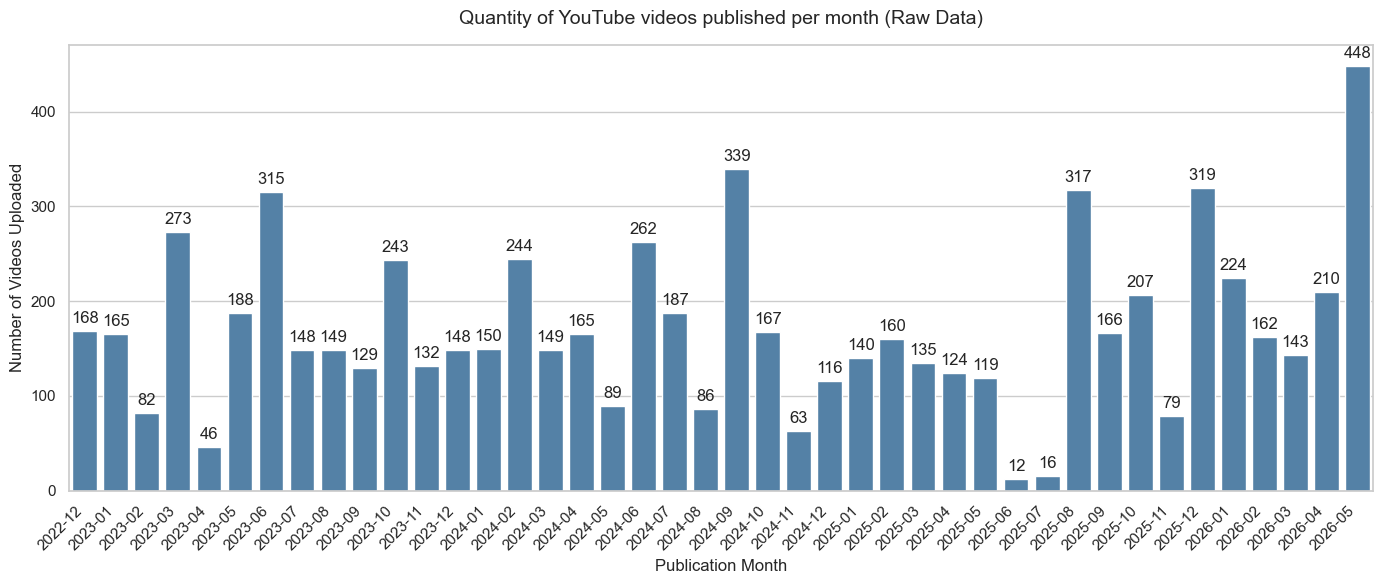

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FILE = "youtube_data/comments_raw.csv" 
video_column = 'Video_ID'
# Usando a coluna que o seu scraper gerou para travar na data do vídeo
publish_month_column = 'Month_Video_Published' 

print(f"Loading raw dataset from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# Garantir que não há linhas vazias e remover duplicatas de comentários 
# para contar apenas 1 ID de vídeo por mês de publicação
df = df.dropna(subset=[publish_month_column, video_column])

# Como a coluna já está no formato 'YYYY-MM', agrupamos direto por ela
monthly_videos = df.groupby(publish_month_column)[video_column].nunique().reset_index(name='Unique_Videos')

# Plotando o Gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=monthly_videos,
    x=publish_month_column,
    y='Unique_Videos',
    color='steelblue'
)

plt.xticks(rotation=45, ha='right')

# Títulos e Labels
plt.title('Quantity of YouTube videos published per month (Raw Data)', fontsize=14, pad=15)
plt.xlabel('Publication Month', fontsize=12)
plt.ylabel('Number of Videos Uploaded', fontsize=12)

# Adicionando os números exatos no topo de cada barra
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.savefig("youtube_data/plot_raw_video_volume_fixed.png", dpi=300)
print("Saved fixed video volume plot: plot_raw_video_volume_fixed.png")

### Plot raw monthly comments

Loading dataset from youtube_data/comments_raw.csv...


/var/folders/kq/34h0_s995y3_98x1qc2wp0380000gn/T/ipykernel_23710/1717283673.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['YearMonth'] = df[date_column].dt.to_period('M')


Saved comment volume plot: plot_comments_volume.png


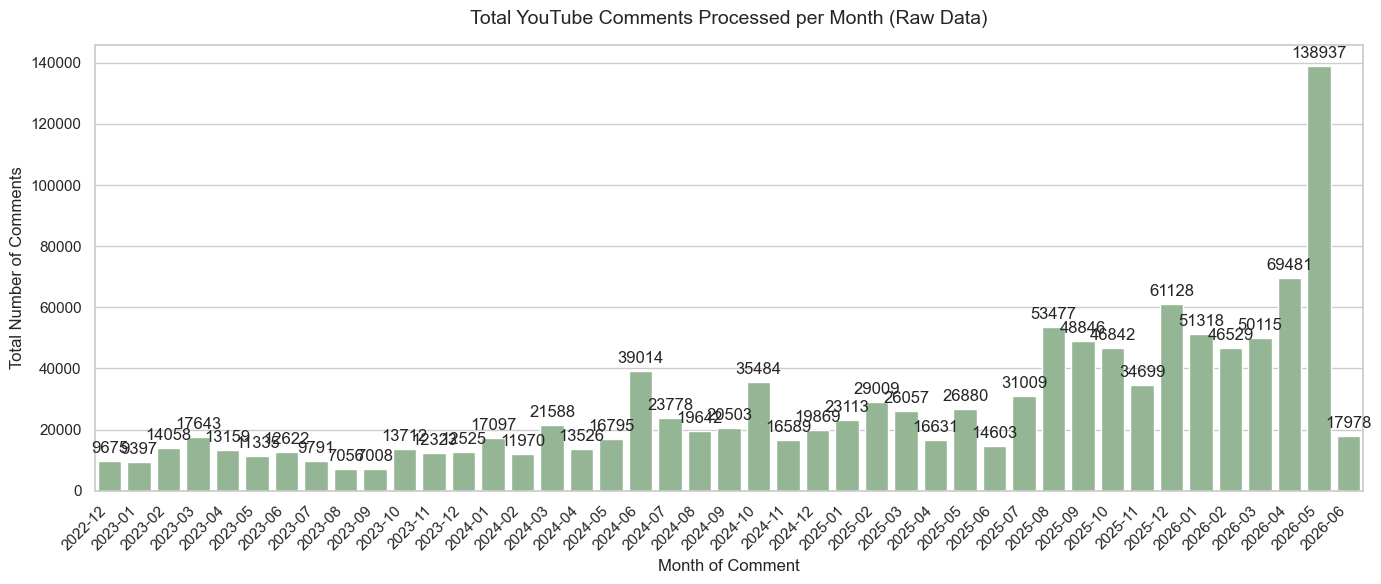

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FILE = "youtube_data/comments_raw.csv" 
date_column = 'Comment_Date' 

print(f"Loading dataset from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# 1. Date Processing
df[date_column] = pd.to_datetime(df[date_column], utc=True, errors='coerce')

# Drop rows missing the date
df = df.dropna(subset=[date_column])

# Extract the Year-Month period
df['YearMonth'] = df[date_column].dt.to_period('M')

# 2. Calculate Total Comments per Month
# size() counts every row (each row is one comment)
monthly_comments = df.groupby('YearMonth').size().reset_index(name='Total_Comments')

# Convert the period back to a standard timestamp for the X-axis
monthly_comments['Date'] = monthly_comments['YearMonth'].dt.to_timestamp()

# 3. Plotting the Chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=monthly_comments,
    x='Date',
    y='Total_Comments',
    color='darkseagreen'
)

# Format the X-axis to cleanly show 'YYYY-MM'
x_dates = monthly_comments['Date'].dt.strftime('%Y-%m')
ax.set_xticks(range(len(x_dates)))
ax.set_xticklabels(x_dates, rotation=45, ha='right')

# Labels and Title
plt.title('Total YouTube comments per Month (Raw Data)', fontsize=14, pad=15)
plt.xlabel('Month of Comment', fontsize=12)
plt.ylabel('Total Number of Comments', fontsize=12)

# Add exact counts on top of each bar for easy reading
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, '.0f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')

plt.tight_layout()
plt.savefig("youtube_data/plot_comments_volume.png", dpi=300)
print("Saved comment volume plot: plot_comments_volume.png")

### Clean and keep English comments

In [7]:
# Force consistent results from langdetect
DetectorFactory.seed = 0

print("Loading raw dataset...")
df = pd.read_csv("youtube_data/comments_raw.csv")
original_count = len(df)
print(f"Starting with {original_count:,} raw rows.")

# --- STEP 1: Drop empty rows and exact duplicates ---
df = df.dropna(subset=['Comment'])
df = df.drop_duplicates(subset=['Video_ID', 'Comment', 'Author'])
print(f"Dropped {original_count - len(df):,} empty or duplicate rows.")

# --- STEP 3: Text Normalization (Cleaning formatting & URLs) ---
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www.\S+', '', text)  # Remove links
    text = re.sub(r'@\w+', '', text)             # Remove mentions
    text = re.sub(r'\s+', ' ', text).strip()     # Clean whitespace
    return text

print("Cleaning text formatting and removing URLs...")
df['Clean_Comment'] = df['Comment'].apply(clean_text)
df = df[df['Clean_Comment'].str.len() > 0]

# --- STEP 4: Language Detection (The Ultimate Safety Net) ---
def is_english(text):
    try:
        if len(text) < 10: 
            return False
        return detect(text) == 'en'
    except:
        return False

print("Filtering for English comments only (this will clean up remaining foreign noise)...")
df['Is_English'] = df['Clean_Comment'].apply(is_english)
df = df[df['Is_English'] == True]

# --- STEP 5: Token Truncation ---
df['Clean_Comment'] = df['Clean_Comment'].str.slice(0, 500)

# --- Save Final Clean Dataset ---
final_columns = ['Month_Video_Published', 'Video_ID', 'Comment_Date', 'Author', 'Likes', 'Reply_Count', 'Clean_Comment']
existing_columns = [col for col in final_columns if col in df.columns]
df_final = df[existing_columns]

output_filename = "youtube_data/comments_CLEANED.csv"
df_final.to_csv(output_filename, index=False, encoding='utf-8')

print(f"\n==================================================")
print(f"PRE-PROCESSING COMPLETE")
print(f"Original Rows: {original_count:,}")
print(f"Final Cleaned Rows: {len(df_final):,}")
print(f"Total Noise Removed: {original_count - len(df_final):,} rows")
print(f"Saved ready-for-analysis dataset to: {output_filename}")
print(f"==================================================")

Loading raw dataset...
Starting with 1,192,811 raw rows.
Dropped 108,621 empty or duplicate rows.
Cleaning text formatting and removing URLs...
Filtering for English comments only (this will clean up remaining foreign noise)...

PRE-PROCESSING COMPLETE
Original Rows: 1,192,811
Final Cleaned Rows: 762,705
Total Noise Removed: 430,106 rows
Saved ready-for-analysis dataset to: youtube_data/comments_CLEANED.csv


### Classify emotions in comments

In [3]:
import pandas as pd
import torch
import gc
import os
from transformers import pipeline
from tqdm.auto import tqdm

# --- 1. Hardware Detection ---
if torch.cuda.is_available():
    device_id = 0
    print("Hardware detected: NVIDIA GPU (CUDA)")
elif torch.backends.mps.is_available():
    device_id = "mps"
    print("Hardware detected: Apple Silicon GPU (MPS)")
else:
    device_id = -1
    print("Hardware: CPU (Warning: This will be slow)")

# --- 2. Configuration & Paths ---
INPUT_FILE = "youtube_data/comments_CLEANED.csv"
OUTPUT_FILE = "youtube_data/comments_CLEANED_with_emotions.csv"
MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

# OPTIMIZATION TUNING:
BATCH_SIZE = 64     # 64 is the sweet spot for matrix multiplication speed on MPS
CHUNK_SIZE = 10000   # We pause every 10k rows to flush memory and save progress

# --- 3. Load Dataset & Setup Checkpointing ---
print(f"Loading dataset from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

# Initialize output columns if they don't exist
if 'Emotion' not in df.columns:
    df['Emotion'] = None
if 'Emotion_Confidence' not in df.columns:
    df['Emotion_Confidence'] = None

# Find where we left off (if the script crashed previously)
start_idx = df['Emotion'].isnull().isna().sum() # Default start if clean
# If resuming an existing file, find the first unclassified row
if os.path.exists(OUTPUT_FILE):
    print(f"Found existing output file. Checking for progress...")
    df_existing = pd.read_csv(OUTPUT_FILE)
    processed_count = df_existing['Emotion'].notna().sum()
    if processed_count > 0:
        df.iloc[:processed_count] = df_existing.iloc[:processed_count]
        start_idx = processed_count
        print(f"Resuming analysis from row index: {start_idx:,}")

text_list = df['Clean_Comment'].astype(str).tolist()

# --- 4. Initialize the AI Pipeline ---
print(f"Loading Hugging Face model: {MODEL_NAME}...")
classifier = pipeline(
    "text-classification", 
    model=MODEL_NAME, 
    device=device_id, 
    return_all_scores=False
)

print(f"Processing remaining {len(text_list) - start_idx:,} rows...")

# --- 5. The Main Checkpointed Loop ---
# We loop through the data in chunks of 10,000
for chunk_start in tqdm(range(start_idx, len(text_list), CHUNK_SIZE), desc="Overall Progress"):
    chunk_end = min(chunk_start + CHUNK_SIZE, len(text_list))
    chunk_texts = text_list[chunk_start:chunk_end]
    
    chunk_emotions = []
    chunk_scores = []
    
    # Run pipeline on the current chunk with strict truncation
    results = classifier(
        chunk_texts, 
        batch_size=BATCH_SIZE, 
        truncation=True, 
        max_length=128  # Eliminates the Padding Trap completely
    )
    
    for out in results:
        chunk_emotions.append(out['label'])
        chunk_scores.append(out['score'])
    
    # Write the chunk results into our main DataFrame
    df.iloc[chunk_start:chunk_end, df.columns.get_loc('Emotion')] = chunk_emotions
    df.iloc[chunk_start:chunk_end, df.columns.get_loc('Emotion_Confidence')] = chunk_scores
    
    # Save progress to disk instantly
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
    
    # --- 6. Memory Flush (The Apple Silicon Fix) ---
    if device_id == "mps":
        torch.mps.empty_cache()
    gc.collect()

print("\n==================================================")
print("CLASSIFICATION COMPLETE!")
print(f"Successfully processed all rows.")
print(f"Final dataset saved to: {OUTPUT_FILE}")
print("==================================================")

Hardware detected: Apple Silicon GPU (MPS)
Loading dataset from youtube_data/comments_CLEANED.csv...
Found existing output file. Checking for progress...


/var/folders/kq/34h0_s995y3_98x1qc2wp0380000gn/T/ipykernel_19362/736507849.py:43: DtypeWarning: Columns (0: Emotion) have mixed types. Specify dtype option on import or set low_memory=False.
  df_existing = pd.read_csv(OUTPUT_FILE)


Resuming analysis from row index: 425,921
Loading Hugging Face model: j-hartmann/emotion-english-distilroberta-base...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 50000.22it/s]


Processing remaining 336,784 rows...


Overall Progress: 100%|██████████| 34/34 [35:35<00:00, 62.82s/it]


CLASSIFICATION COMPLETE!
Successfully processed all rows.
Final dataset saved to: youtube_data/comments_CLEANED_with_emotions.csv


### Filter by confidence score

In [8]:
# --- 1. Load the classified dataset ---
input_file = "youtube_data/comments_CLEANED_with_emotions.csv"
output_file = "youtube_data/comments_HIGH_CONFIDENCE.csv"

print(f"Loading data from {input_file}...")
df = pd.read_csv(input_file)
initial_count = len(df)

# --- 2. Set your threshold ---
# Example: 0.60 means we only keep rows where the model is 60% confident or higher
CONFIDENCE_THRESHOLD = 0.75

print(f"Filtering rows where Emotion_Confidence is less than {CONFIDENCE_THRESHOLD * 100}%...")

# --- 3. Apply the filter ---
# Keep only rows above or equal to the threshold
df_filtered = df[df['Emotion_Confidence'] >= CONFIDENCE_THRESHOLD]
final_count = len(df_filtered)

# --- 4. Save the filtered dataset ---
df_filtered.to_csv(output_file, index=False, encoding='utf-8')

# --- 5. Report Metrics ---
rows_dropped = initial_count - final_count
percent_dropped = (rows_dropped / initial_count) * 100

print("\n==================================================")
print("FILTERING COMPLETE!")
print(f"Original Rows: {initial_count:,}")
print(f"Rows Retained: {final_count:,}")
print(f"Rows Dropped:  {rows_dropped:,} ({percent_dropped:.2f}%)")
print(f"Saved highly confident dataset to: {output_file}")
print("==================================================")

Loading data from youtube_data/comments_CLEANED_with_emotions.csv...
Filtering rows where Emotion_Confidence is less than 75.0%...

FILTERING COMPLETE!
Original Rows: 762,705
Rows Retained: 379,749
Rows Dropped:  382,956 (50.21%)
Saved highly confident dataset to: youtube_data/comments_HIGH_CONFIDENCE.csv


### Classify comment targets

In [ ]:
import pandas as pd
import torch
import gc
import os
from transformers import pipeline
from tqdm.auto import tqdm

# --- 1. Hardware Detection ---
if torch.cuda.is_available():
    device_id = 0
    print("Hardware detected: NVIDIA GPU (CUDA)")
elif torch.backends.mps.is_available():
    device_id = "mps"
    print("Hardware detected: Apple Silicon GPU (MPS)")
else:
    device_id = -1
    print("Hardware detected: CPU")

# --- 2. Configuration & Checkpoint Paths ---
INPUT_FILE = "youtube_data/comments_HIGH_CONFIDENCE.csv"
PROGRESS_FILE = "youtube_data/comments_TARGET_PROGRESS.csv" # <--- New! Saves state safely
OUTPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"

# OPTIMIZATION TUNING:
# BART is a massive model. 16 is the safest batch limit to prevent Mac memory leaks.
# We checkpoint every 1,024 rows so you never lose more than a minute of work.
BATCH_SIZE = 16  
CHUNK_SIZE = 1024 

# --- 3. Load Dataset & Setup Checkpointing ---
print(f"Loading high-confidence dataset from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

# Ensure columns exist before we start injecting data
if 'Comment_Target' not in df.columns:
    df['Comment_Target'] = None
if 'Target_Confidence' not in df.columns:
    df['Target_Confidence'] = None

start_idx = 0

# Check if we crashed and need to resume!
if os.path.exists(PROGRESS_FILE):
    print("Found existing progress file. Checking status...")
    df_progress = pd.read_csv(PROGRESS_FILE)
    processed_count = df_progress['Comment_Target'].notna().sum()
    
    if processed_count > 0:
        # Restore the successfully processed data into our current dataframe
        df.iloc[:processed_count] = df_progress.iloc[:processed_count]
        start_idx = processed_count
        print(f"✅ Resuming aspect classification from row: {start_idx:,}")

text_list = df['Clean_Comment'].astype(str).tolist()

# --- 4. Initialize the Pipeline ---
MODEL_NAME = "facebook/bart-large-mnli"
print(f"Loading Zero-Shot Transformer model: {MODEL_NAME}...")
classifier = pipeline(
    "zero-shot-classification", 
    model=MODEL_NAME, 
    device=device_id
)

candidate_labels = [
    "financial speculation, stock market investing, and economic tech bubbles",
    "practical software development, system architecture, and real-world ai productivity",
    "existential fears, job replacement, and the societal impact of artificial intelligence",
    "feedback about the youtube video production or content creator"
]

print(f"Processing remaining {len(text_list) - start_idx:,} rows...")

# --- 5. The Main Checkpointed Loop ---
for chunk_start in tqdm(range(start_idx, len(text_list), CHUNK_SIZE), desc="Overall Progress"):
    chunk_end = min(chunk_start + CHUNK_SIZE, len(text_list))
    chunk_texts = text_list[chunk_start:chunk_end]
    
    # Run pipeline with explicit truncation to prevent the padding trap
    results = classifier(
        chunk_texts, 
        candidate_labels, 
        batch_size=BATCH_SIZE, 
        truncation=True, 
        max_length=256
    )
    
    chunk_targets = []
    chunk_scores = []
    
    # Unpack the highest scoring label for each comment
    for out in results:
        chunk_targets.append(out['labels'][0])
        chunk_scores.append(out['scores'][0])
        
    # Inject the chunk data directly into the dataframe
    df.iloc[chunk_start:chunk_end, df.columns.get_loc('Comment_Target')] = chunk_targets
    df.iloc[chunk_start:chunk_end, df.columns.get_loc('Target_Confidence')] = chunk_scores
    
    # Save the current state to the disk immediately
    df.to_csv(PROGRESS_FILE, index=False, encoding='utf-8')
    
    # --- 6. Memory Flush (The Apple Silicon Fix) ---
    if device_id == "mps":
        torch.mps.empty_cache()
    gc.collect()

# --- 7. The Macroeconomic Clean Slice ---
print("\nExtraction Complete! Generating final filtered dataset...")

# Keep all three core AI perspectives, drop the video feedback/noise
valid_targets = candidate_labels[:3]
df_ai_only = df[df['Comment_Target'].isin(valid_targets)]

# Save the final, clean, ready-to-graph dataset!
df_ai_only.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')

# --- 8. Analytics & Metrics Report ---
speculation_count = len(df[df['Comment_Target'] == candidate_labels[0]])
utility_count = len(df[df['Comment_Target'] == candidate_labels[1]])
society_count = len(df[df['Comment_Target'] == candidate_labels[2]])
noise_count = len(df) - len(df_ai_only)

print("\n==================================================")
print("ASPECT FILTERING & DISAMBIGUATION COMPLETE!")
print(f"Total Comments Processed: {len(df):,}")
print(f"--------------------------------------------------")
print(f"Hype/Finance:   {speculation_count:,} rows")
print(f"Utility/Systems:   {utility_count:,} rows")
print(f"Social/Fear:   {society_count:,} rows")
print(f"Video Production Noise Dropped:   {noise_count:,} rows")
print(f"--------------------------------------------------")
print(f"Saved final pristine dataset to: {OUTPUT_FILE}")
print("==================================================")

### Print dataset target summary

In [14]:
import pandas as pd

INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"
df = pd.read_csv(INPUT_FILE)

print("=== DATASET SUMMARY ===")
print(f"Total Comments: {len(df):,}\n")

print("DISTRIBUTION")
summary_df = pd.DataFrame({
    'Count': df['Comment_Target'].value_counts(),
    'Share (%)': (df['Comment_Target'].value_counts(normalize=True) * 100).round(2)
})
print(summary_df.to_string())
print("\n")

print("CONFIDENCE METRICS")
confidence_df = df.groupby('Comment_Target')['Target_Confidence'].agg(
    Mean='mean', Min='min', Max='max'
).round(4)
print(confidence_df.to_string())
print("\n")

print("EXAMPLES")
for category in df['Comment_Target'].unique():
    print(f"\n[{category.upper()}]")
    top_comments = df[df['Comment_Target'] == category].nlargest(2, 'Target_Confidence')
    for _, row in top_comments.iterrows():
        text = str(row['Clean_Comment'])
        display_text = text[:200] + "..." if len(text) > 200 else text
        print(f"Score: {row['Target_Confidence']:.4f} | {display_text}")

=== DATASET SUMMARY ===
Total Comments: 145,247

DISTRIBUTION
                                                                                        Count  Share (%)
Comment_Target                                                                                          
existential fears, job replacement, and the societal impact of artificial intelligence  78593      54.11
practical software development, system architecture, and real-world ai productivity     58319      40.15
financial speculation, stock market investing, and economic tech bubbles                 8335       5.74


CONFIDENCE METRICS
                                                                                          Mean     Min     Max
Comment_Target                                                                                                
existential fears, job replacement, and the societal impact of artificial intelligence  0.5494  0.2553  0.9958
financial speculation, stock market investing, and economic

### Rank emotions by narrative

Reading dataset from youtube_data/comments_TARGET_FILTERED.csv...

EMOTION RANKING ENTIRE DATASET
Rank 1: Neutral      | Count: 105353 | Share: 72.53%
Rank 2: Surprise     | Count: 9681   | Share: 6.67%
Rank 3: Fear         | Count: 9265   | Share: 6.38%
Rank 4: Joy          | Count: 5909   | Share: 4.07%
Rank 5: Anger        | Count: 5701   | Share: 3.93%
Rank 6: Disgust      | Count: 5060   | Share: 3.48%
Rank 7: Sadness      | Count: 4278   | Share: 2.95%

EMOTION RANKINGS BY AI MACRO NARRATIVE

> Label: Financial Speculation
----------------------------------------
  Rank 1: Neutral      | Count: 5809   | Share: 69.69%
  Rank 2: Surprise     | Count: 717    | Share: 8.60%
  Rank 3: Disgust      | Count: 447    | Share: 5.36%
  Rank 4: Joy          | Count: 388    | Share: 4.66%
  Rank 5: Anger        | Count: 375    | Share: 4.50%
  Rank 6: Fear         | Count: 355    | Share: 4.26%
  Rank 7: Sadness      | Count: 244    | Share: 2.93%

> Label: Societal Impact & Fear
------------

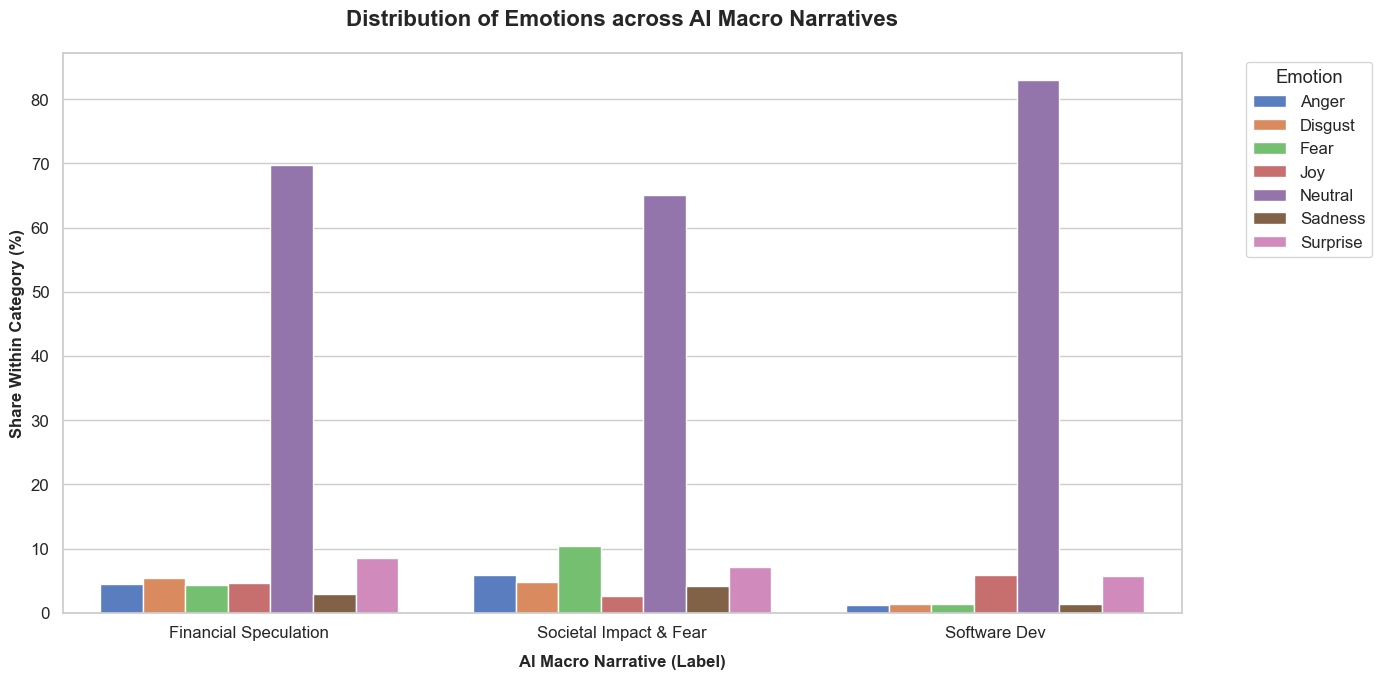

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"
emotion_column = 'Emotion'
label_column = 'Comment_Target'

print(f"Reading dataset from {INPUT_FILE}...\n")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# Clean and standardize values
df = df.dropna(subset=[emotion_column, label_column])
df[emotion_column] = df[emotion_column].str.title()

# Map long category descriptions to shorter labels for cleaner output and plotting
label_map = {
    'existential fears, job replacement, and the societal impact of artificial intelligence': 'Societal Impact & Fear',
    'practical software development, system architecture, and real-world ai productivity': 'Software Dev',
    'financial speculation, stock market investing, and economic tech bubbles': 'Financial Speculation'
}
df['Macro_Narrative'] = df[label_column].map(label_map).fillna(df[label_column])

# ==========================================
# 1. GLOBAL EMOTION RANKING
# ==========================================
print("=" * 60)
print("EMOTION RANKING ENTIRE DATASET")
print("=" * 60)
general_counts = df[emotion_column].value_counts()
general_pct = df[emotion_column].value_counts(normalize=True) * 100

for rank, (emotion, count) in enumerate(general_counts.items(), 1):
    pct = general_pct[emotion]
    print(f"Rank {rank}: {emotion:<12} | Count: {count:<6} | Share: {pct:.2f}%")

# ==========================================
# 2. EMOTION RANKING PER MACRO NARRATIVE (LABEL)
# ==========================================
print("\n" + "=" * 60)
print("EMOTION RANKINGS BY AI MACRO NARRATIVE")
print("=" * 60)

grouped = df.groupby('Macro_Narrative')[emotion_column]

for name, group in grouped:
    print(f"\n> Label: {name}")
    print("-" * 40)
    cat_counts = group.value_counts()
    cat_pct = group.value_counts(normalize=True) * 100
    
    for rank, (emotion, count) in enumerate(cat_counts.items(), 1):
        pct = cat_pct[emotion]
        print(f"  Rank {rank}: {emotion:<12} | Count: {count:<6} | Share: {pct:.2f}%")

# ==========================================
# 3. VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(14, 7))

# Normalize data per row (narrative) to show percentage distributions
plot_data = pd.crosstab(df['Macro_Narrative'], df[emotion_column], normalize='index').stack().reset_index(name='Proportion')
plot_data['Percentage'] = plot_data['Proportion'] * 100

ax = sns.barplot(
    data=plot_data,
    x='Macro_Narrative',
    y='Percentage',
    hue=emotion_column,
    palette='muted'
)

plt.title('Distribution of Emotions across AI Macro Narratives', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('AI Macro Narrative (Label)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Share Within Category (%)', fontsize=12, fontweight='bold')
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("youtube_data/emotion_rankings_by_label.png", dpi=300, bbox_inches='tight')
print("\n" + "=" * 60)
print("Comparative chart saved to: youtube_data/emotion_rankings_by_label.png")
print("=" * 60)

### Calculate neutral comment share

In [7]:
import pandas as pd

INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"
emotion_column = 'Emotion'

df = pd.read_csv(INPUT_FILE, low_memory=False)

# Drop rows that don't have an emotion assigned just to be safe
df = df.dropna(subset=[emotion_column])

total_comments = len(df)
# Use str.lower() to ensure we catch 'Neutral', 'neutral', or 'NEUTRAL'
neutral_comments = len(df[df[emotion_column].str.lower() == 'neutral'])

percentage = (neutral_comments / total_comments) * 100

print("=== NEUTRAL COMMENTS ===")
print(f"Total Comments: {total_comments:,}")
print(f"Neutral Comments: {neutral_comments:,}")
print(f"Percentage: {percentage:.2f}%")

=== NEUTRAL COMMENTS ===
Total Comments: 145,247
Neutral Comments: 105,353
Percentage: 72.53%


### Plot filtered monthly comments

Loading dataset from youtube_data/comments_TARGET_FILTERED.csv...


/var/folders/kq/34h0_s995y3_98x1qc2wp0380000gn/T/ipykernel_23710/1646549886.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['YearMonth'] = df[date_column].dt.to_period('M')


Saved comment volume plot: plot_comments_volume.png


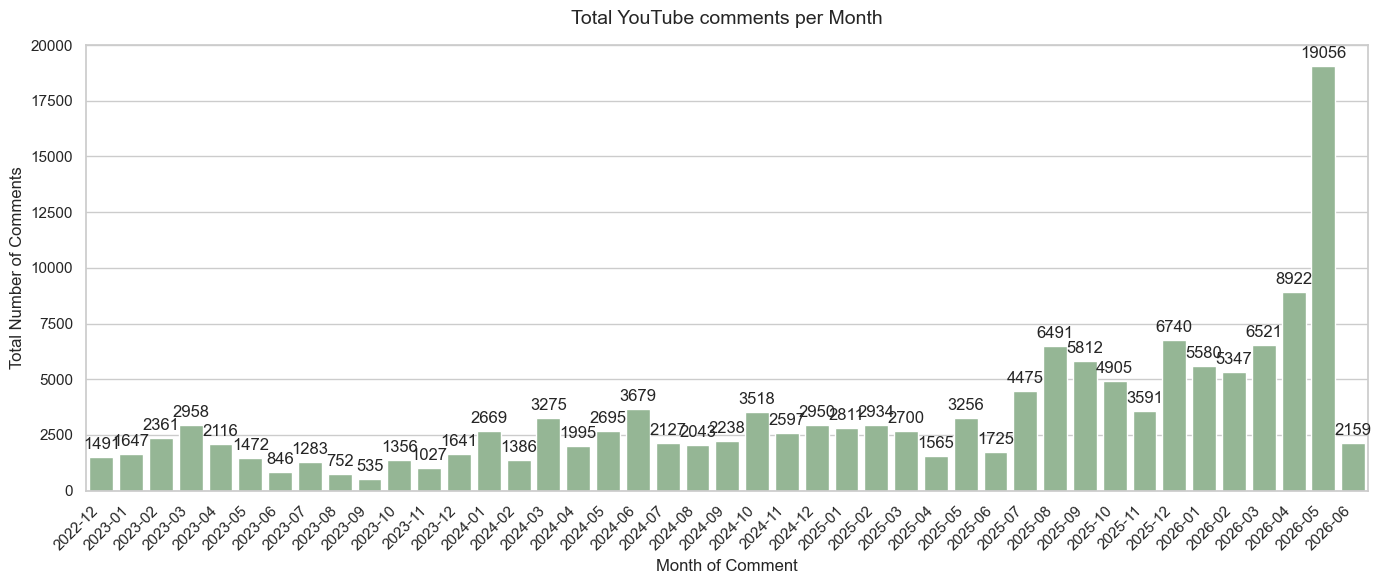

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv" 
date_column = 'Comment_Date' 

print(f"Loading dataset from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# 1. Date Processing
df[date_column] = pd.to_datetime(df[date_column], utc=True, errors='coerce')

# Drop rows missing the date
df = df.dropna(subset=[date_column])

# Extract the Year-Month period
df['YearMonth'] = df[date_column].dt.to_period('M')

# 2. Calculate Total Comments per Month
# size() counts every row (each row is one comment)
monthly_comments = df.groupby('YearMonth').size().reset_index(name='Total_Comments')

# Convert the period back to a standard timestamp for the X-axis
monthly_comments['Date'] = monthly_comments['YearMonth'].dt.to_timestamp()

# 3. Plotting the Chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=monthly_comments,
    x='Date',
    y='Total_Comments',
    color='darkseagreen'
)

# Format the X-axis to cleanly show 'YYYY-MM'
x_dates = monthly_comments['Date'].dt.strftime('%Y-%m')
ax.set_xticks(range(len(x_dates)))
ax.set_xticklabels(x_dates, rotation=45, ha='right')

# Labels and Title
plt.title('Total YouTube comments per Month', fontsize=14, pad=15)
plt.xlabel('Month of Comment', fontsize=12)
plt.ylabel('Total Number of Comments', fontsize=12)

# Add exact counts on top of each bar for easy reading
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, '.0f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')

plt.tight_layout()
plt.savefig("youtube_data/plot_comments_volume.png", dpi=300)
print("Saved comment volume plot: plot_comments_volume.png")

### Plot emotion timeline

Loading dataset for emotion timeline visualization...


/var/folders/kq/34h0_s995y3_98x1qc2wp0380000gn/T/ipykernel_23710/3398089853.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['YearMonth'] = df[date_column].dt.to_period('M')


Saved timeline plot: plot_emotions_timeline.png


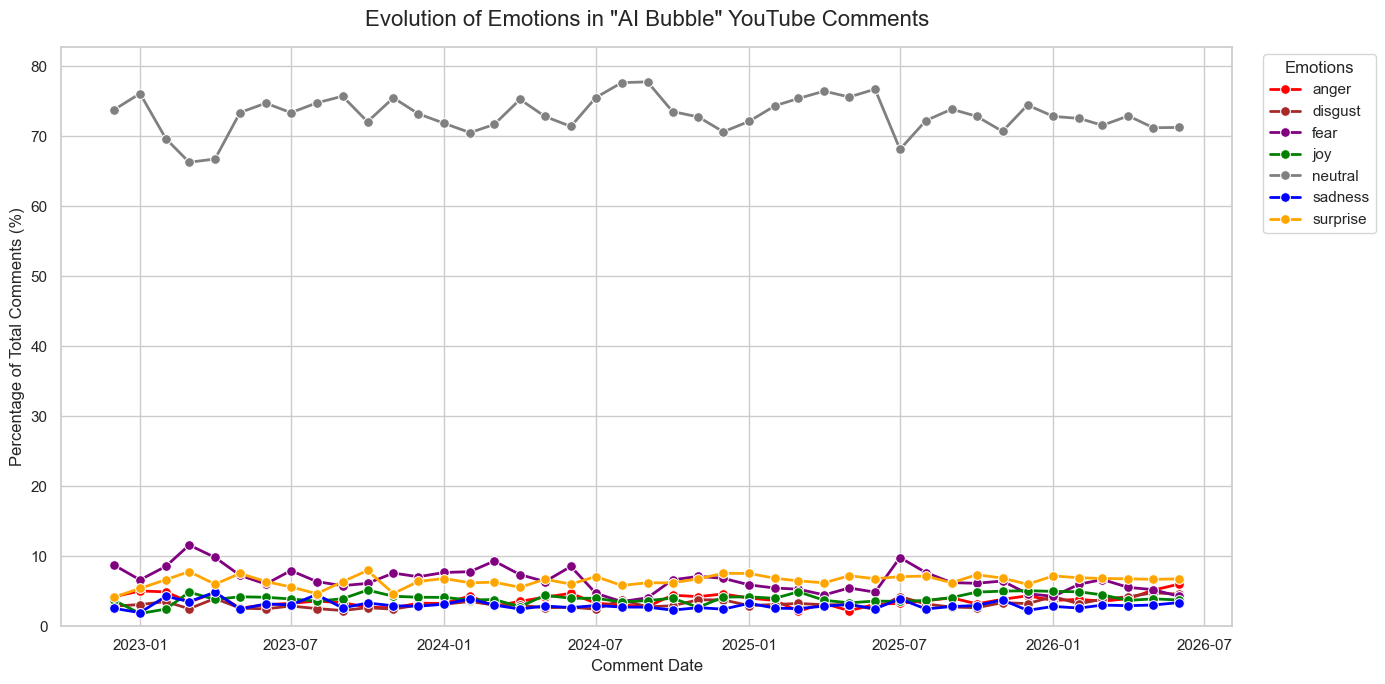

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Update this to the file that contains your emotion classifications
INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv" 
date_column = 'Comment_Date' # Update to your actual date column name
emotion_column = 'Emotion'   # Update to your actual emotion column name

print("Loading dataset for emotion timeline visualization...")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# 1. Date Processing
df[date_column] = pd.to_datetime(df[date_column], utc=True, errors='coerce')

# Drop rows missing either the date or the emotion label
df = df.dropna(subset=[date_column, emotion_column])

# Extract the Year-Month period to group the data
df['YearMonth'] = df[date_column].dt.to_period('M')

# 2. Calculate Percentages over Time
# Group by month and emotion to get raw counts
monthly_counts = df.groupby(['YearMonth', emotion_column]).size().reset_index(name='Count')

# Calculate the total comments per month to find the percentage
monthly_totals = monthly_counts.groupby('YearMonth')['Count'].transform('sum')
monthly_counts['Percentage'] = (monthly_counts['Count'] / monthly_totals) * 100

# Convert YearMonth back to timestamp for plotting
monthly_counts['Date'] = monthly_counts['YearMonth'].dt.to_timestamp()

# 3. Plotting the Chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Match the exact color palette from your attached image
emotion_palette = {
    'anger': 'red',
    'disgust': 'brown',
    'fear': 'purple',
    'joy': 'green',
    'neutral': 'grey',
    'sadness': 'blue',
    'surprise': 'orange'
}

ax = sns.lineplot(
    data=monthly_counts,
    x='Date',
    y='Percentage',
    hue=emotion_column,
    palette=emotion_palette,
    marker='o',
    markersize=7,
    linewidth=2
)

# Title and Labels
plt.title('Evolution of Emotions in "AI Bubble" YouTube Comments', fontsize=16, pad=15)
plt.xlabel('Comment Date', fontsize=12)
plt.ylabel('Percentage of Total Comments (%)', fontsize=12)

# Ensure y-axis starts at 0 
plt.ylim(0, max(monthly_counts['Percentage']) + 5)

# Format legend to match the image style
plt.legend(title='Emotions', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("youtube_data/plot_emotions_timeline.png", dpi=300)
print("Saved timeline plot: plot_emotions_timeline.png")

### Plot timeline without neutral

Loading dataset for emotion timeline visualization...


/var/folders/kq/34h0_s995y3_98x1qc2wp0380000gn/T/ipykernel_23710/820716250.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['YearMonth'] = df[date_column].dt.to_period('M')


Saved timeline plot: plot_emotions_timeline_no_neutral.png


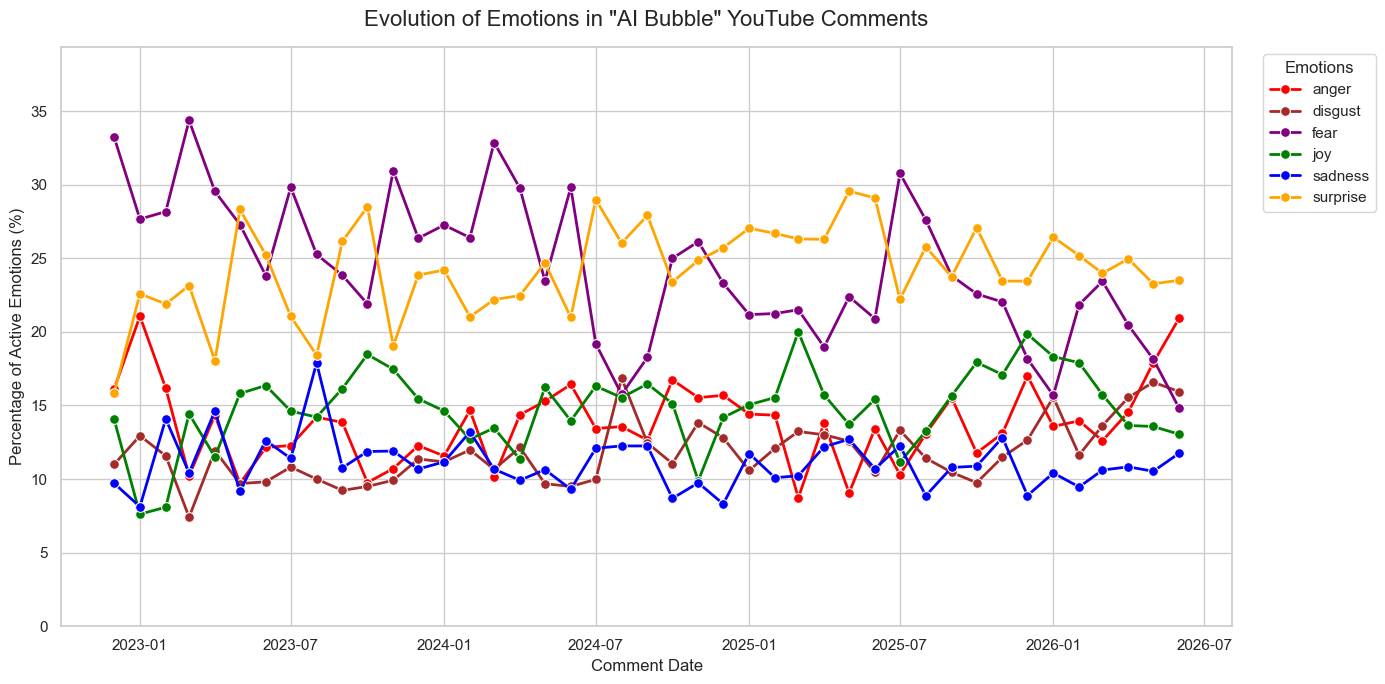

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Update this to the file that contains your emotion classifications
INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv" 
date_column = 'Comment_Date' 
emotion_column = 'Emotion'   

print("Loading dataset for emotion timeline visualization...")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# 1. Date Processing
df[date_column] = pd.to_datetime(df[date_column], utc=True, errors='coerce')

# Drop rows missing either the date or the emotion label
df = df.dropna(subset=[date_column, emotion_column])

# --- CRITICAL CHANGE: Remove 'neutral' from the dataset ---
# We convert to lowercase just to be safe (neutral vs Neutral)
df = df[df[emotion_column].str.lower() != 'neutral']

# Extract the Year-Month period to group the data
df['YearMonth'] = df[date_column].dt.to_period('M')

# 2. Calculate Percentages over Time
# Group by month and emotion to get raw counts
monthly_counts = df.groupby(['YearMonth', emotion_column]).size().reset_index(name='Count')

# Calculate the total comments per month to find the percentage
monthly_totals = monthly_counts.groupby('YearMonth')['Count'].transform('sum')
monthly_counts['Percentage'] = (monthly_counts['Count'] / monthly_totals) * 100

# Convert YearMonth back to timestamp for plotting
monthly_counts['Date'] = monthly_counts['YearMonth'].dt.to_timestamp()

# 3. Plotting the Chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Removed 'neutral' from the dictionary
emotion_palette = {
    'anger': 'red',
    'disgust': 'brown',
    'fear': 'purple',
    'joy': 'green',
    'sadness': 'blue',
    'surprise': 'orange'
}

ax = sns.lineplot(
    data=monthly_counts,
    x='Date',
    y='Percentage',
    hue=emotion_column,
    palette=emotion_palette,
    marker='o',
    markersize=7,
    linewidth=2
)

# Title and Labels
plt.title('Evolution of Emotions in "AI Bubble" YouTube Comments', fontsize=16, pad=15)
plt.xlabel('Comment Date', fontsize=12)
plt.ylabel('Percentage of Active Emotions (%)', fontsize=12)

# Ensure y-axis starts at 0 
plt.ylim(0, max(monthly_counts['Percentage']) + 5)

# Format legend to match the image style
plt.legend(title='Emotions', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("youtube_data/plot_emotions_timeline_no_neutral.png", dpi=300)
print("Saved timeline plot: plot_emotions_timeline_no_neutral.png")

### Heatmap labels vs emotions

Loading dataset from youtube_data/comments_TARGET_FILTERED.csv...
Saved premium heatmap: plot_emotion_correlation_beautiful.png


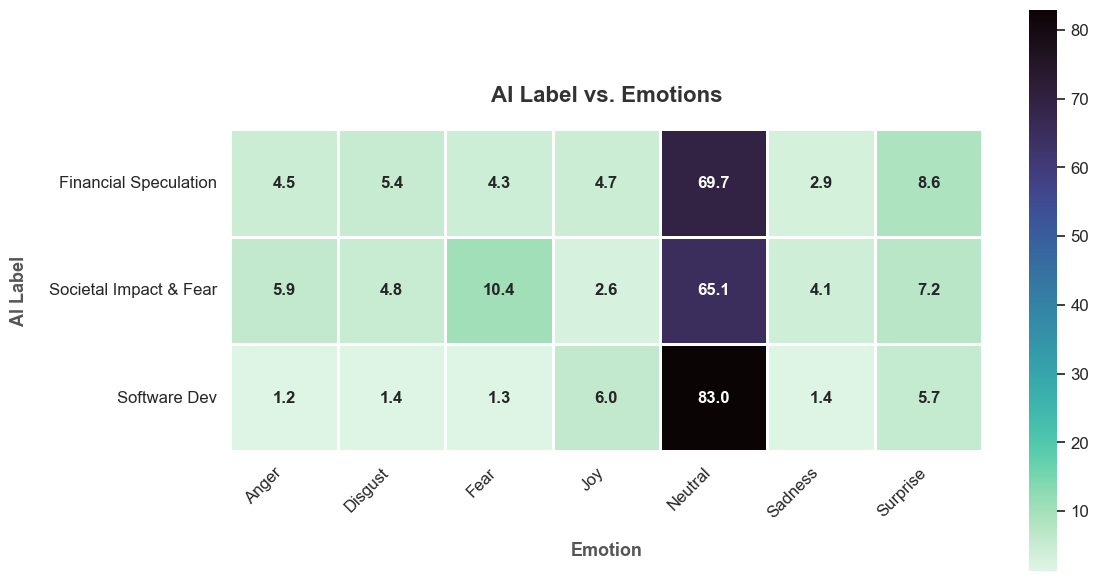

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"
emotion_column = 'Emotion'

print(f"Loading dataset from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# 1. Limpar e padronizar os dados
df = df.dropna(subset=['Comment_Target', emotion_column])
df[emotion_column] = df[emotion_column].str.title()

# 2. Encurtar os rótulos das categorias
label_map = {
    'existential fears, job replacement, and the societal impact of artificial intelligence': 'Societal Impact & Fear',
    'practical software development, system architecture, and real-world ai productivity': 'Software Dev',
    'financial speculation, stock market investing, and economic tech bubbles': 'Financial Speculation'
}
df['AI_Perspective'] = df['Comment_Target'].map(label_map)

# 3. Criar a Tabela de Contingência (Crosstab)
cross_tab = pd.crosstab(df['AI_Perspective'], df[emotion_column], normalize='index') * 100

# --- CONFIGURAÇÕES ESTÉTICAS PREMIUM ---

# Fundo totalmente branco e minimalista, sem grades de fundo atrapalhando
sns.set_theme(style="white", font_scale=1.1)

# Aumentar levemente o canvas para as células respirarem
plt.figure(figsize=(12, 7))

# Criando o Heatmap
ax = sns.heatmap(
    cross_tab, 
    annot=True,          
    fmt=".1f",           
    cmap="mako_r",                        # Paleta elegante (Menta para Azul Escuro)
    linewidths=2,                         # Bordas grossas entre os quadrados
    linecolor='white',                    # Cor da grade limpa
    square=True,                          # Força os blocos a serem quadrados perfeitos
    annot_kws={"size": 12, "weight": "bold"}, # Números maiores e em negrito
    cbar_kws={
        'shrink': 0.85,                   # Deixa a barra lateral mais fina e elegante
        'pad': 0.05                       # Afasta a barra levemente do gráfico
    }
)

# Estilização de Títulos e Eixos
plt.title('AI Label vs. Emotions', fontsize=16, pad=20, fontweight='bold', color='#333333')
plt.xlabel('Emotion', fontsize=13, fontweight='bold', color='#555555', labelpad=15)
plt.ylabel('AI Label', fontsize=13, fontweight='bold', color='#555555', labelpad=15)

# Limpeza visual dos "ticks" (aqueles tracinhos pretos nos eixos)
ax.tick_params(left=False, bottom=False)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()

# 5. Salvar o arquivo
plt.savefig("youtube_data/plot_emotion_correlation_beautiful.png", dpi=300, bbox_inches='tight')
print("Saved premium heatmap: plot_emotion_correlation_beautiful.png")

### Download stock market data

In [29]:
import yfinance as yf

# Update to a list of tickers
TICKERS = ["NVDA", "AIQ", "THNQ"]

print(f"Fetching stock data for {', '.join(TICKERS)} from {DEFAULT_START_DATE.year} to {END_DATE.year}...")

# Download the historical data for all tickers at once
# Setting interval="1mo" groups the stock data by month to match your emotion graph
stock_data = yf.download(
    TICKERS, 
    start=DEFAULT_START_DATE.strftime('%Y-%m-%d'), 
    end=END_DATE.strftime('%Y-%m-%d'),
    interval="1mo" 
)

print("Data fetched successfully!")

# Display the first few rows to verify the data structure
stock_data.head()

Fetching stock data for NVDA, AIQ, THNQ from 2022 to 2026...


[*********************100%***********************]  2 of 3 completed

Data fetched successfully!


Price           Close                             High                        \
Ticker            AIQ       NVDA       THNQ        AIQ       NVDA       THNQ   
2022-12-01  19.938892  14.581600  26.246819  21.922862  18.748342  28.971300   
2023-01-01  22.741821  19.493690  30.167875  23.328771  20.582272  31.745678   
2023-02-01  22.443365  23.164530  30.647902  24.452922  23.835041  33.072988   
2023-03-01  24.462873  27.715422  32.419312  24.512614  27.772295  32.424302   
2023-04-01  23.706804  27.692184  30.321562  24.492721  28.052445  32.251653   

Price             Low                             Open                        \
Ticker            AIQ       NVDA       THNQ        AIQ       NVDA       THNQ   
2022-12-01  19.423060  13.853218  25.318701  21.506228  16.961313  28.312634   
2023-01-01  19.996089  14.002889  25.478378  20.244797  14.818078  26.725850   
2023-02-01  22.055382  19.567523  30.154901  22.910936  19.647345  30.717762   
2023-03-01  21.488332  22.247571  29.180873  22.542851  23.140585  30.877436   
2023-04-01  22.731871  26.166314  29.818581  24.293754  27.452676  32.184787   

Price        Volume                       
Ticker          AIQ         NVDA    THNQ  
2022-12-01   596400   8946152000   58000  
2023-01-01   966900   9454960000   69500  
2023-02-01   764500  10393479000  119500  
2023-03-01   707400  11263731000   71800  
2023-04-01  1109500   7436450000  110400

### Plot NVDA and ETFs

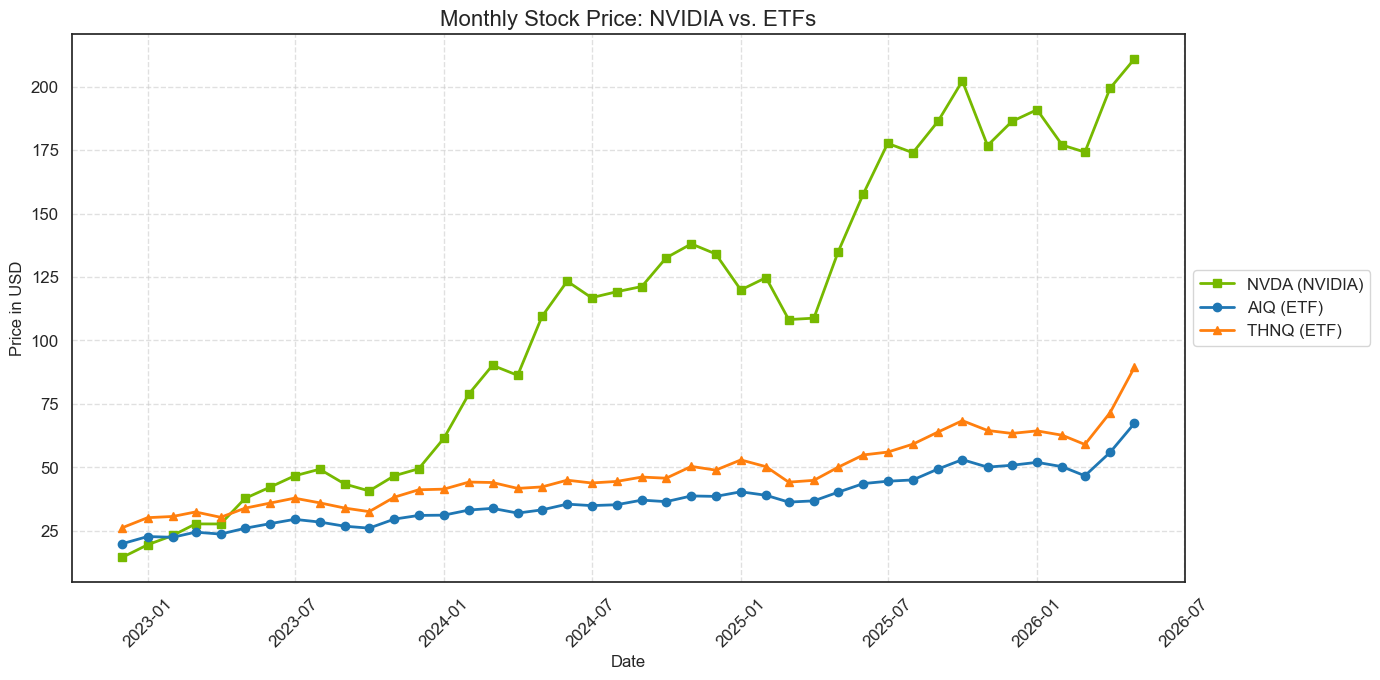

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# 1. Plot NVIDIA (The Hardware Giant)
plt.plot(
    stock_data.index, 
    stock_data['Close']['NVDA'], 
    marker='s',              
    color='#76b900',         # NVIDIA's brand green
    linewidth=2,
    label='NVDA (NVIDIA)'
)

# 2. Plot AIQ (Broad AI & Tech ETF)
plt.plot(
    stock_data.index, 
    stock_data['Close']['AIQ'], 
    marker='o',              # Circle markers
    color='#1f77b4',         # Blue
    linewidth=2,
    label='AIQ (ETF)'
)

# 3. Plot THNQ (Robotics & AI ETF)
plt.plot(
    stock_data.index, 
    stock_data['Close']['THNQ'], 
    marker='^',              # Triangle markers
    color='#ff7f0e',         # Orange
    linewidth=2,
    label='THNQ (ETF)'
)

plt.title('Monthly Stock Price: NVIDIA vs. ETFs', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Placed legend outside the main graph area to avoid blocking data lines
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.tight_layout()

# Show the graph
plt.show()

### Correlate emotions and stocks

1. Processing YouTube Emotion Data...


/var/folders/kq/34h0_s995y3_98x1qc2wp0380000gn/T/ipykernel_23710/4206551280.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_emo['YearMonth'] = df_emo[date_column].dt.to_period('M')
[*********************100%***********************]  3 of 3 completed


2. Fetching Market Data for NVDA, AIQ, THNQ...
3. Merging and Calculating Correlation...
4. Generating Visualization...
Complete! Saved as plot_market_sentiment_correlation.png


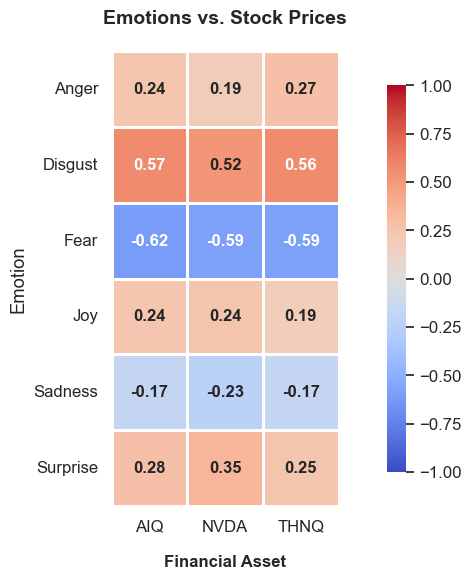

In [45]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"
date_column = 'Comment_Date'
emotion_column = 'Emotion'
TICKERS = ["NVDA", "AIQ", "THNQ"]

print("1. Processing YouTube Emotion Data...")
df_emo = pd.read_csv(INPUT_FILE, low_memory=False)

# Clean and format dates/emotions
df_emo = df_emo.dropna(subset=[date_column, emotion_column])
df_emo[date_column] = pd.to_datetime(df_emo[date_column], utc=True)
df_emo[emotion_column] = df_emo[emotion_column].str.title()

# Remove 'Neutral' to isolate active market sentiment
df_emo = df_emo[df_emo[emotion_column] != 'Neutral']

# Group by Month and Calculate Percentages
df_emo['YearMonth'] = df_emo[date_column].dt.to_period('M')
monthly_counts = df_emo.groupby(['YearMonth', emotion_column]).size().unstack(fill_value=0)
monthly_pct = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100

print(f"2. Fetching Market Data for {', '.join(TICKERS)}...")
# Fetch stock data starting slightly before your YouTube dataset to ensure alignment
start_date = str(monthly_pct.index.min().start_time.date())
end_date = str(monthly_pct.index.max().end_time.date())

stock_data = yf.download(TICKERS, start=start_date, end=end_date, interval="1mo")
stock_close = stock_data['Close'].dropna(how='all')

# Align the stock timeline index to match the YouTube YearMonth index
stock_close.index = stock_close.index.to_period('M')

print("3. Merging and Calculating Correlation...")
# Merge the two datasets strictly where dates overlap
merged_data = pd.concat([monthly_pct, stock_close], axis=1, join='inner')

# Calculate the correlation matrix
correlation_matrix = merged_data.corr()

# Isolate just the cross-section between Emotions (rows) and Stocks (columns)
emotions_list = monthly_pct.columns
stocks_list = stock_close.columns
cross_correlation = correlation_matrix.loc[emotions_list, stocks_list]

print("4. Generating Visualization...")
sns.set_theme(style="white", font_scale=1.1)
plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    cross_correlation, 
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",      # Red = Positive Correlation, Blue = Negative Correlation
    center=0,             
    vmin=-1, vmax=1,      
    linewidths=2,         
    linecolor='white',    
    square=True,          
    annot_kws={"size": 12, "weight": "bold"}, 
    cbar_kws={
        'shrink': 0.85,   
        'pad': 0.05       
    }
)

plt.title('Emotions vs. Stock Prices', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Financial Asset', fontsize=12, fontweight='bold', labelpad=15)

plt.xticks(fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

plt.savefig("youtube_data/plot_market_sentiment_correlation.png", dpi=300, bbox_inches='tight')
print("Complete! Saved as plot_market_sentiment_correlation.png")

### Extract financial video comments

In [10]:
import pandas as pd

# --- CONFIGURATION ---
INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"
TARGET_VIDEO_ID = "rf9Sat5n0AQ"
NUMBER_OF_SAMPLES = 20 

# Exact financial label string used by your pipeline
FINANCIAL_CONTEXT = 'financial speculation, stock market investing, and economic tech bubbles'

print(f"Reading dataset to extract financial comments for video: {TARGET_VIDEO_ID}...\n")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# 1. Apply Dual Filters: Specific Video AND Financial Target
video_filter = df['Video_ID'] == TARGET_VIDEO_ID
narrative_filter = df['Comment_Target'] == FINANCIAL_CONTEXT

df_financial = df[video_filter & narrative_filter].copy()

if df_financial.empty:
    print(f"Notice: No comments were classified under the financial narrative for video '{TARGET_VIDEO_ID}'.")
    print("This implies the model mapped this video's audience focus entirely to Societal Impact or Practical Dev.")
    exit()

print(f"Found {len(df_financial)} comments classified as Financial Speculation for this video.")
print(f"Displaying up to {min(NUMBER_OF_SAMPLES, len(df_financial))} samples:\n")

# Take the top rows to sample
sample_df = df_financial.head(NUMBER_OF_SAMPLES)

print("=" * 80)
print(f"FINANCIAL CONTEXT SAMPLES FOR VIDEO: {TARGET_VIDEO_ID}")
print("=" * 80)

for index, row in sample_df.iterrows():
    comment_text = row.get('Comment', row.get('Clean_Comment', 'N/A'))
    emotion = str(row.get('Emotion', 'N/A')).title()
    
    # Handle model classification confidence safely if the column exists
    confidence_str = ""
    if 'Target_Confidence' in row:
        confidence_str = f" | Confidence: {row['Target_Confidence']:.2f}"
    elif 'Confidence' in row:
        confidence_str = f" | Confidence: {row['Confidence']:.2f}"

    print(f"➔ [FINANCIAL] Emotion: {emotion}{confidence_str}")
    print(f"💬 \"{comment_text}\"")
    print("-" * 80)

# 2. Save a dedicated CSV with ONLY this video's financial debate for easy access
output_csv = f"youtube_data/financial_debate_{TARGET_VIDEO_ID}.csv"
df_financial.to_csv(output_csv, index=False)
print(f"\n[Saved File] All {len(df_financial)} financial rows saved to: {output_csv}")

Reading dataset to extract financial comments for video: rf9Sat5n0AQ...

Found 88 comments classified as Financial Speculation for this video.
Displaying up to 20 samples:

FINANCIAL CONTEXT SAMPLES FOR VIDEO: rf9Sat5n0AQ
➔ [FINANCIAL] Emotion: Neutral | Confidence: 0.59
💬 "I hope when ai bubble bursts, it will not drag down real tech achievements such Google search and useful ai research."
--------------------------------------------------------------------------------
➔ [FINANCIAL] Emotion: Neutral | Confidence: 0.38
💬 "Brad should sell his shares. I hope he took Sams advice seriously."
--------------------------------------------------------------------------------
➔ [FINANCIAL] Emotion: Anger | Confidence: 0.42
💬 "*The US Economy. Everyone else has been wisely reducing their exposure to risk in the US since you elected the clown party the second time. We will be fine. 92% of US GDP growth is the AI bubble. You folks are FUCKED lmao."
------------------------------------------------

### Plot labels over time

Loading dataset from youtube_data/comments_TARGET_FILTERED.csv...


/var/folders/kq/34h0_s995y3_98x1qc2wp0380000gn/T/ipykernel_24924/3974009947.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['YearMonth'] = df[date_column].dt.to_period('M')



[Success] Time-series trend plot saved to: youtube_data/plot_labels_over_time.png


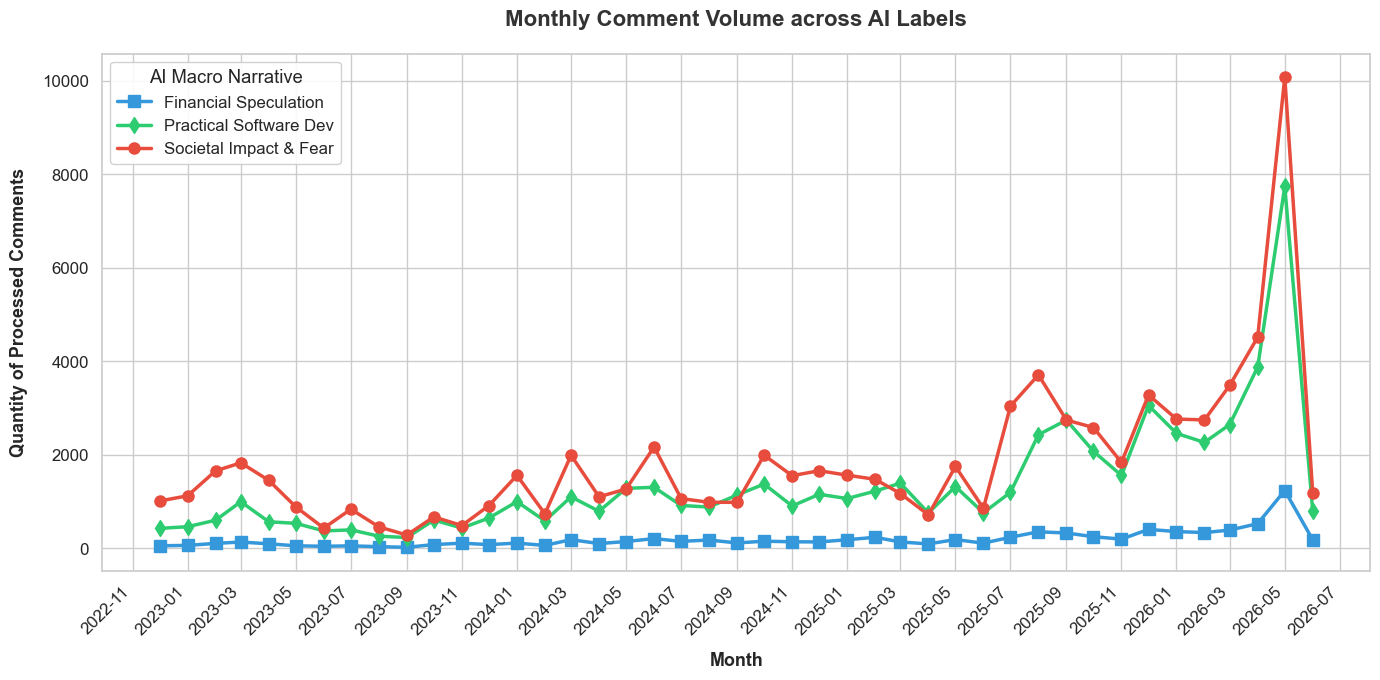

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

INPUT_FILE = "youtube_data/comments_TARGET_FILTERED.csv"
date_column = 'Comment_Date'
label_column = 'Comment_Target'

print(f"Loading dataset from {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE, low_memory=False)

# 1. Clean data and parse dates
df = df.dropna(subset=[date_column, label_column])
df[date_column] = pd.to_datetime(df[date_column], utc=True, errors='coerce')
df = df.dropna(subset=[date_column])

# Extract the Year-Month period
df['YearMonth'] = df[date_column].dt.to_period('M')

# 2. Map long classification targets to cleaner, shorter labels
label_map = {
    'existential fears, job replacement, and the societal impact of artificial intelligence': 'Societal Impact & Fear',
    'practical software development, system architecture, and real-world ai productivity': 'Practical Software Dev',
    'financial speculation, stock market investing, and economic tech bubbles': 'Financial Speculation'
}
df['Macro_Narrative'] = df[label_column].map(label_map).fillna(df[label_column])

# 3. Aggregate data: Count comments per month for each category
# This produces a DataFrame where index=Months and columns=The 3 Narratives
monthly_counts = df.groupby(['YearMonth', 'Macro_Narrative']).size().unstack(fill_value=0)

# Convert the PeriodIndex back to standard Timestamps for smooth Matplotlib rendering
monthly_counts.index = monthly_counts.index.to_timestamp()

# 4. Plotting (Premium Theme)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(14, 7))

# Explicit distinct colors and markers for academic/report quality
palette = {
    'Societal Impact & Fear': '#e74c3c',   # Deep Crimson
    'Practical Software Dev': '#2ecc71',   # Emerald Green
    'Financial Speculation': '#3498db'    # Royal Blue
}
markers = {
    'Societal Impact & Fear': 'o',
    'Software Dev': '^',
    'Financial Speculation': 's'
}

# Plot each narrative series dynamically
for narrative in monthly_counts.columns:
    plt.plot(
        monthly_counts.index,
        monthly_counts[narrative],
        marker=markers.get(narrative, 'd'),
        color=palette.get(narrative, '#7f8c8d'),
        linewidth=2.5,
        markersize=8,
        label=narrative
    )

# Formatting Titles, Labels, and Legends
plt.title('Monthly Comment Volume across AI Labels', fontsize=16, pad=20, fontweight='bold', color='#333333')
plt.xlabel('Month', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Quantity of Processed Comments', fontsize=13, fontweight='bold', labelpad=10)

# Format the X-axis date intervals cleanly (showing every 2 months to prevent overlapping strings)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')

# Style legend area
plt.legend(title='AI Macro Narrative', loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

# 5. Save the final asset
output_path = "youtube_data/plot_labels_over_time.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n[Success] Time-series trend plot saved to: {output_path}")

### Merge sentiment and NVDA

In [ ]:
# 1. Flatten the MultiIndex from yfinance to a single level
if isinstance(nvda_data.columns, pd.MultiIndex):
    # This grabs the 'Close' category and renames the underlying 'NVDA' column
    nvda_close = nvda_data['Close'].copy()
    nvda_close.columns = ['NVDA_Price']
else:
    # Fallback for older versions of yfinance
    nvda_close = nvda_data[['Close']].rename(columns={'Close': 'NVDA_Price'})

# 2. Ensure the indexes align perfectly (sometimes timezones get in the way)
temporal_data_pct.index = temporal_data_pct.index.tz_localize(None)
nvda_close.index = nvda_close.index.tz_localize(None)

# 3. Merge the two DataFrames based on their Date indexes
merged_df = temporal_data_pct.join(nvda_close, how='inner')

print("Data merged successfully! Here is a peek:")
merged_df.head()

Data merged successfully! Here is a peek:


,anger,disgust,fear,joy,neutral,sadness,surprise,NVDA_Price
Month,,,,,,,,
2024-01-01,3.697183,4.753521,2.464789,10.211268,71.302817,2.464789,5.105634,61.489414
2024-02-01,4.251969,4.566929,2.204724,15.433071,57.165354,3.937008,12.440945,79.063675
2024-03-01,5.655172,3.310345,3.586207,14.344828,57.517241,4.000000,11.586207,90.300812
2024-04-01,5.081081,9.621622,8.756757,5.837838,60.648649,3.351351,6.702703,86.353279
2024-05-01,5.326232,8.255659,2.263648,5.725699,68.175766,3.328895,6.924101,109.571159


### Compute NVDA correlations

In [11]:
# Calculate the correlation matrix
correlation_matrix = merged_df.corr()

# Extract just how the emotions correlate with the NVIDIA price
nvda_correlations = correlation_matrix['NVDA_Price'].drop('NVDA_Price')

# Sort them to see the strongest correlations at the top
nvda_correlations = nvda_correlations.sort_values(ascending=False)

print("Correlation with NVIDIA Stock Price:\n")
print(nvda_correlations)

Correlation with NVIDIA Stock Price:

anger       0.533590
surprise    0.525557
fear        0.365791
disgust     0.173859
sadness     0.168332
joy        -0.166575
neutral    -0.553173
Name: NVDA_Price, dtype: float64


### Plot top emotion vs NVDA

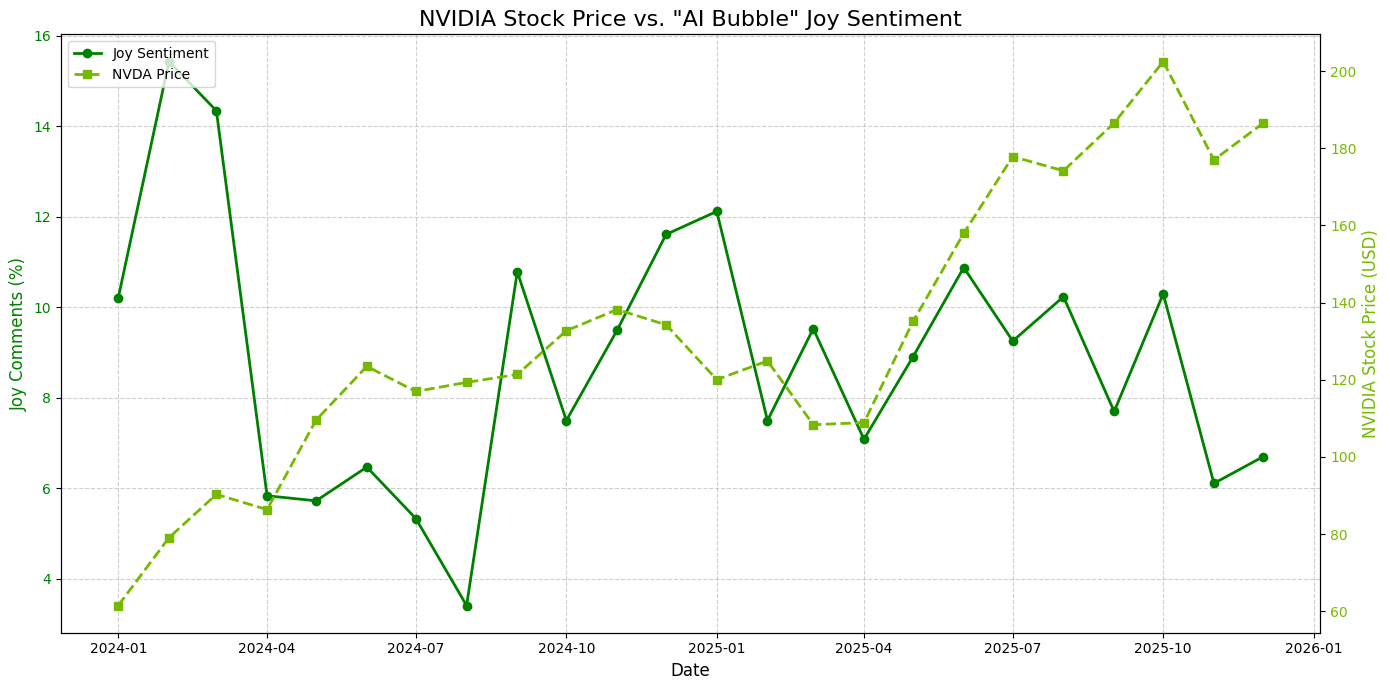

In [15]:
# Let's plot the strongest correlating emotion
TARGET_EMOTION = 'joy'  

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Plot 1: The Emotion (Left Y-Axis) ---
color_emotion = 'green'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel(f'{TARGET_EMOTION.capitalize()} Comments (%)', color=color_emotion, fontsize=12)
ax1.plot(merged_df.index, merged_df[TARGET_EMOTION], color=color_emotion, marker='o', linewidth=2, label=f'{TARGET_EMOTION.capitalize()} Sentiment')
ax1.tick_params(axis='y', labelcolor=color_emotion)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()  

# --- Plot 2: NVDA Stock (Right Y-Axis) ---
color_stock = '#76b900'
ax2.set_ylabel('NVIDIA Stock Price (USD)', color=color_stock, fontsize=12)
ax2.plot(merged_df.index, merged_df['NVDA_Price'], color=color_stock, marker='s', linewidth=2, linestyle='--', label='NVDA Price')
ax2.tick_params(axis='y', labelcolor=color_stock)

# --- Add the Unified Legend ---
# Extract lines and labels from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine them into a single legend on ax1
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Add titles and adjust layout
plt.title(f'NVIDIA Stock Price vs. "{SEARCH_QUERY}" {TARGET_EMOTION.capitalize()} Sentiment', fontsize=16)
fig.tight_layout()

# Show the dual-axis graph
plt.show()

### Smooth and recalculate correlation

In [14]:
# Choose a smoothing window (1 = raw data, 2-3 = smoothed trends)
rolling_months = 2

# Apply rolling average to smooth out month-to-month noise
smoothed_df = merged_df.rolling(window=rolling_months, min_periods=1).mean()

# Calculate the correlation matrix on the smoothed data
correlation_matrix = smoothed_df.corr()

# Extract how every emotion correlates specifically with the NVIDIA Stock Price
nvda_correlations = correlation_matrix['NVDA_Price'].drop('NVDA_Price').sort_values(ascending=False)

print(f"--- Pearson Correlation Coefficients (with {rolling_months}-Month Smoothing) ---")
print("Scale: 1.0 (Perfect Positive), -1.0 (Perfect Negative), 0.0 (No Correlation)\n")

for emotion, score in nvda_correlations.items():
    status = "Positive (Moves with Stock)" if score > 0 else "Negative (Inverse Mirror)"
    print(f"{emotion.capitalize():<10} : {score:>6.2f} ({status})")


--- Pearson Correlation Coefficients (with 2-Month Smoothing) ---
Scale: 1.0 (Perfect Positive), -1.0 (Perfect Negative), 0.0 (No Correlation)

Anger      :   0.67 (Positive (Moves with Stock))
Surprise   :   0.66 (Positive (Moves with Stock))
Fear       :   0.54 (Positive (Moves with Stock))
Disgust    :   0.24 (Positive (Moves with Stock))
Sadness    :   0.23 (Positive (Moves with Stock))
Joy        :  -0.23 (Negative (Inverse Mirror))
Neutral    :  -0.68 (Negative (Inverse Mirror))


### Build emotion vs NVDA dashboard

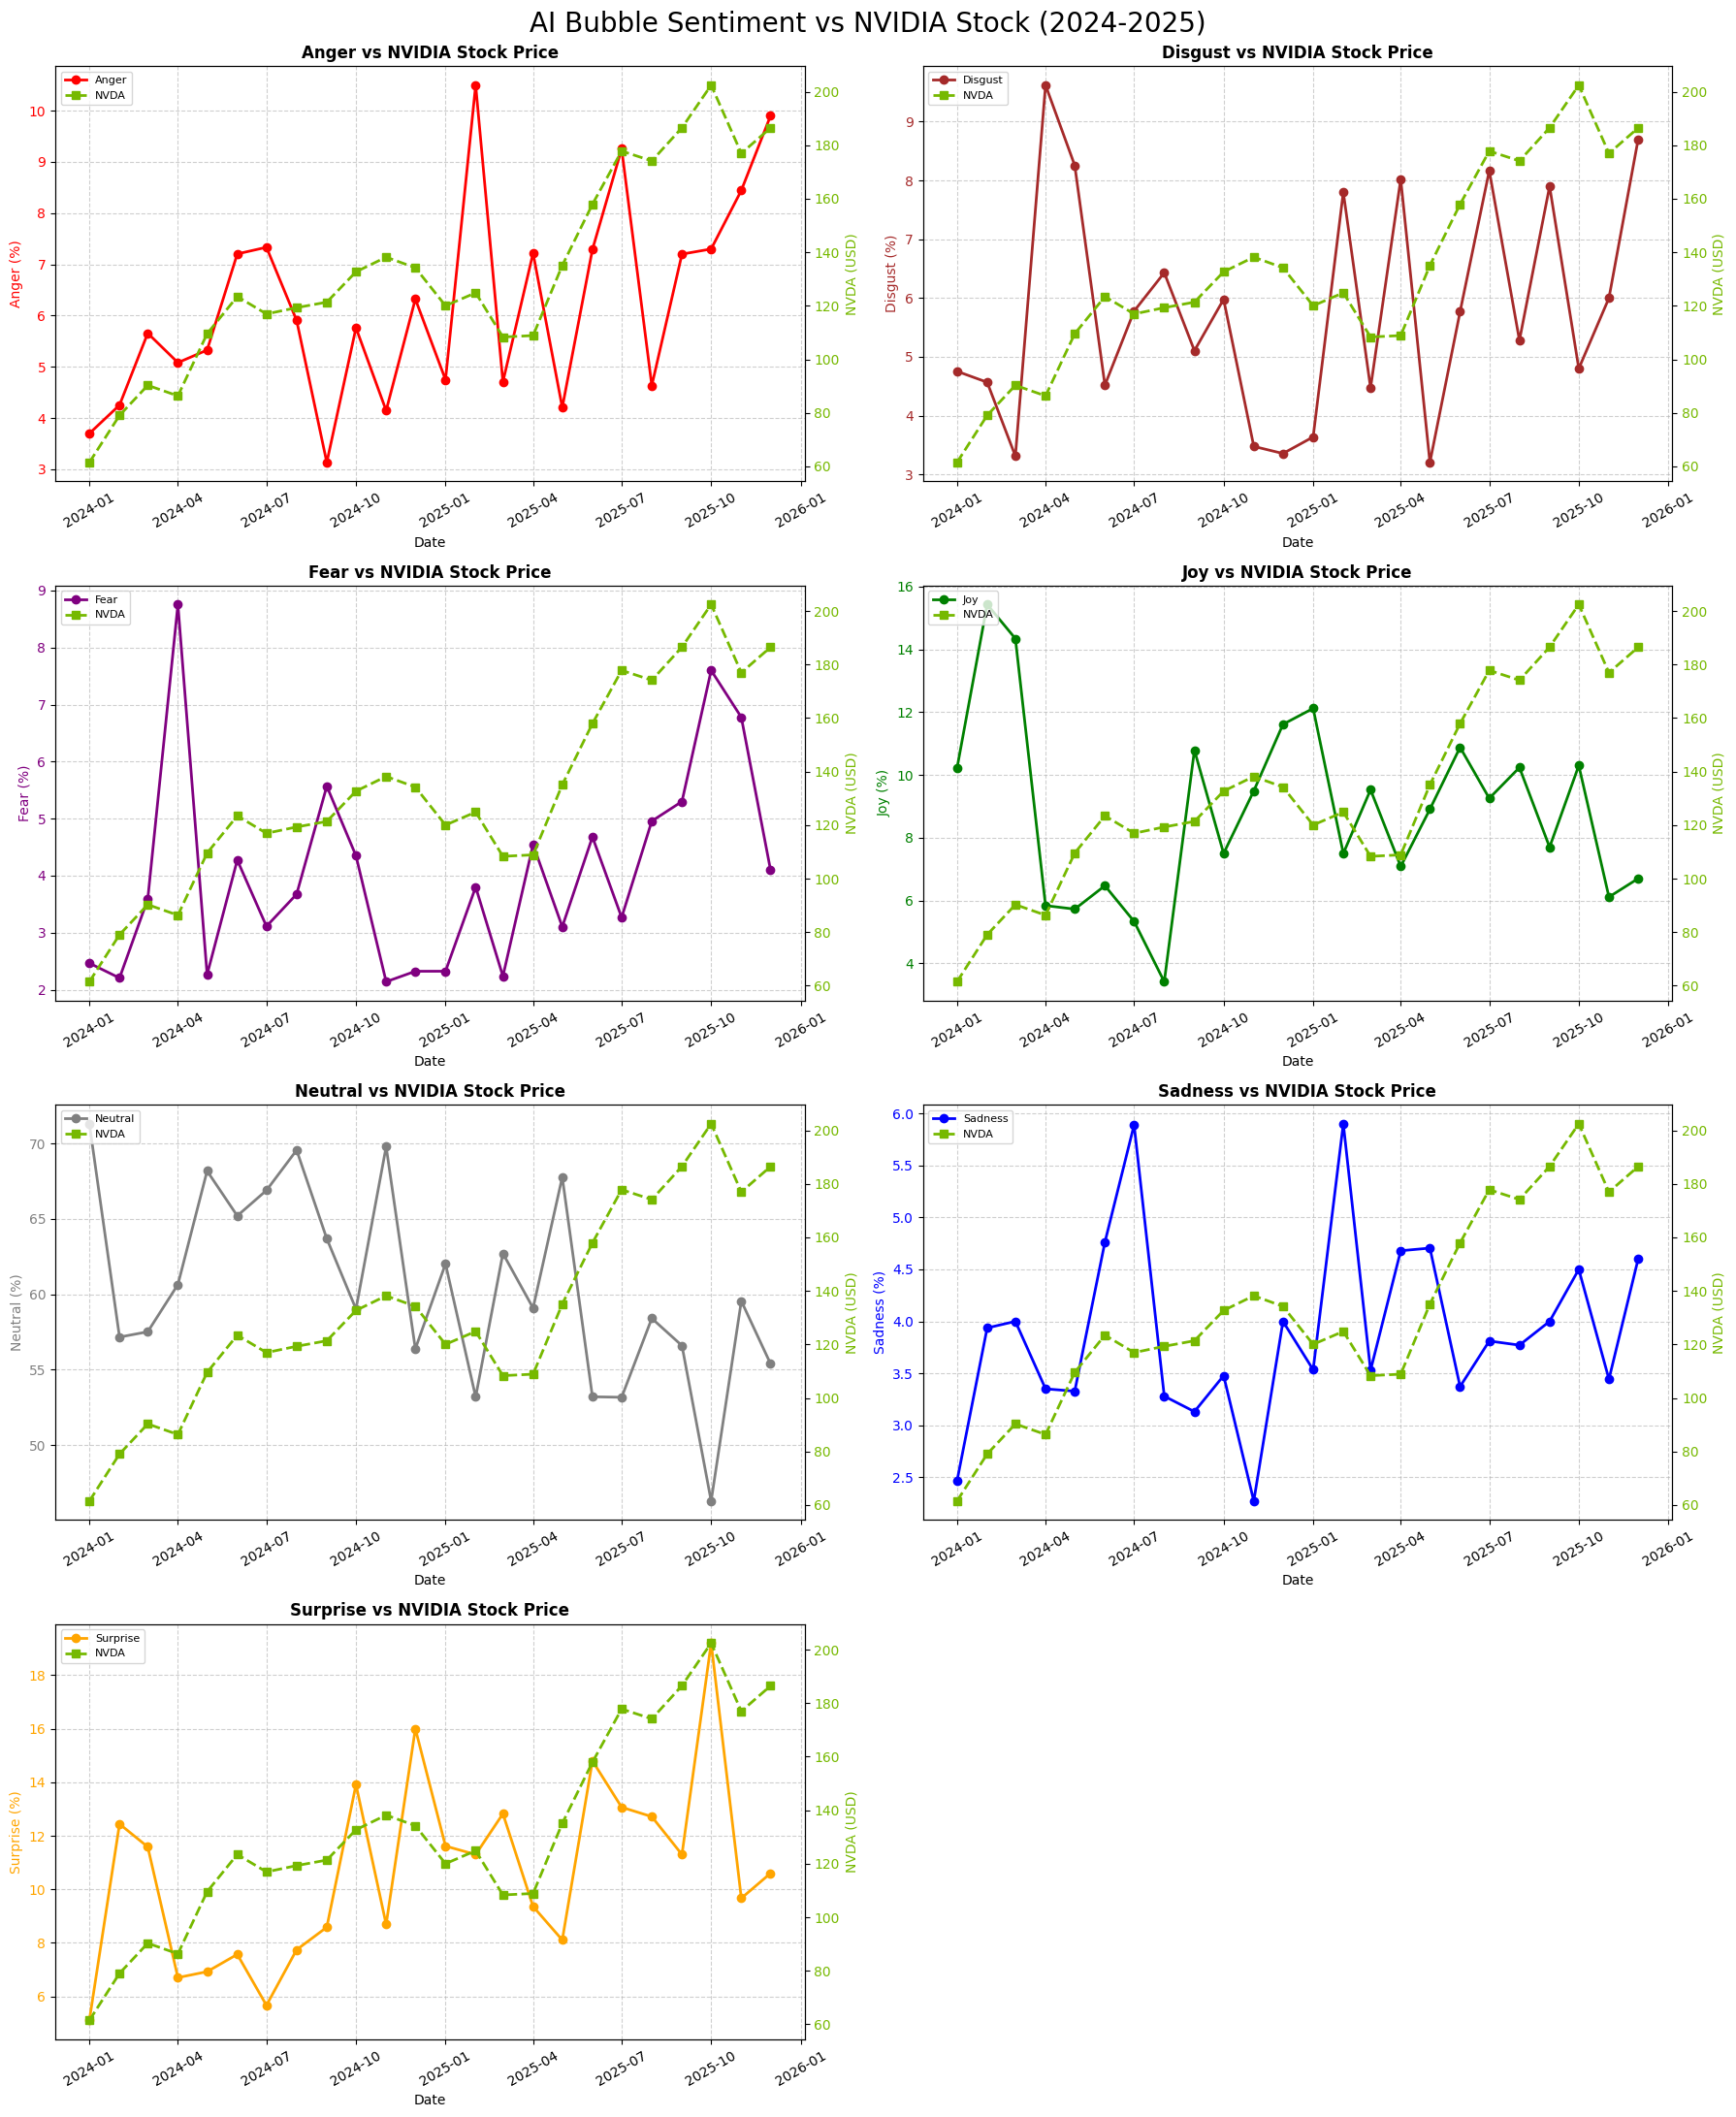

In [24]:
# Extract just the emotion column names
emotions_list = [col for col in merged_df.columns if col != 'NVDA_Price']

# Define our consistent color palette for the emotions
emotion_colors = {
    'anger': 'red', 'disgust': 'brown', 'fear': 'purple', 
    'joy': 'green', 'neutral': 'gray', 'sadness': 'blue', 'surprise': 'orange'
}

# The consistent NVIDIA brand color
color_stock = '#76b900'

# Create a 4x2 grid of subplots (4 rows, 2 columns)
# We set a large figure size so the charts aren't cramped
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 22))

# Flatten the 2D array of axes into a simple 1D list so we can loop through it easily
axes = axes.flatten()

# Loop through each emotion and assign it to a specific subplot axis
for i, emotion in enumerate(emotions_list):
    ax1 = axes[i] # Select the current subplot slot
    color_emotion = emotion_colors.get(emotion, 'black')
    
    # --- Plot 1: The Emotion (Left Y-Axis) ---
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel(f'{emotion.capitalize()} (%)', color=color_emotion, fontsize=10)
    ax1.plot(merged_df.index, merged_df[emotion], color=color_emotion, marker='o', linewidth=2, label=f'{emotion.capitalize()}')
    ax1.tick_params(axis='y', labelcolor=color_emotion)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Create a second Y-axis that shares the same X-axis for this specific subplot
    ax2 = ax1.twinx()  

    # --- Plot 2: NVDA Stock (Right Y-Axis) ---
    ax2.set_ylabel('NVDA (USD)', color=color_stock, fontsize=10)
    ax2.plot(merged_df.index, merged_df['NVDA_Price'], color=color_stock, marker='s', linewidth=2, linestyle='--', label='NVDA')
    ax2.tick_params(axis='y', labelcolor=color_stock)

    # --- Add the Unified Legend ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8)

    # Add a title to this specific subplot
    ax1.set_title(f'{emotion.capitalize()} vs NVIDIA Stock Price', fontsize=12, fontweight='bold')
    
    # Rotate the date labels slightly so they fit cleanly
    ax1.tick_params(axis='x', rotation=30)

# We only have 7 emotions, but our grid holds 8 plots. 
# This hides the 8th (empty) slot so it looks professional.
axes[7].set_visible(False)

# Add a main title for the entire dashboard
fig.suptitle('AI Bubble Sentiment vs NVIDIA Stock (2024-2025)', fontsize=20, y=0.99)

# Automatically adjust the padding so nothing overlaps
fig.tight_layout()

# Show the master grid!
plt.show()

### Fetch YouTube Trends data

In [34]:
from pytrends.request import TrendReq
import pandas as pd

print("Connecting to Google Trends...")

# Initialize the pytrends API
# hl='en-US' sets language, tz=360 is US Central Time (standard default)
pytrends = TrendReq(hl='en-US', tz=360)

# Define our parameters
kw_list = [SEARCH_QUERY] # Uses 'AI Bubble' from your Cell 2 configuration
timeframe_str = f"{DEFAULT_START_DATE.strftime('%Y-%m-%d')} {END_DATE.strftime('%Y-%m-%d')}"

print(f"Fetching YouTube search interest for '{SEARCH_QUERY}' between {timeframe_str}...")

# Build the payload. 
# gprop='youtube' is the magic parameter that filters strictly for YouTube searches!
pytrends.build_payload(
    kw_list, 
    cat=0, 
    timeframe=timeframe_str, 
    gprop='youtube'
)

# Fetch the interest over time
youtube_trends_df = pytrends.interest_over_time()

if not youtube_trends_df.empty:
    # Drop the 'isPartial' column as we don't need it for the graph
    youtube_trends_df = youtube_trends_df.drop(labels=['isPartial'], axis='columns')
    print("Data fetched successfully!")
    display(youtube_trends_df.head())
else:
    print("No search data found for this specific query and timeframe.")

Connecting to Google Trends...
Fetching YouTube search interest for 'AI' between 2022-12-01 2026-05-31...
Data fetched successfully!


,AI
date,
2022-11-27,32
2022-12-04,32
2022-12-11,34
2022-12-18,35
2022-12-25,35


### Plot YouTube Trends chart

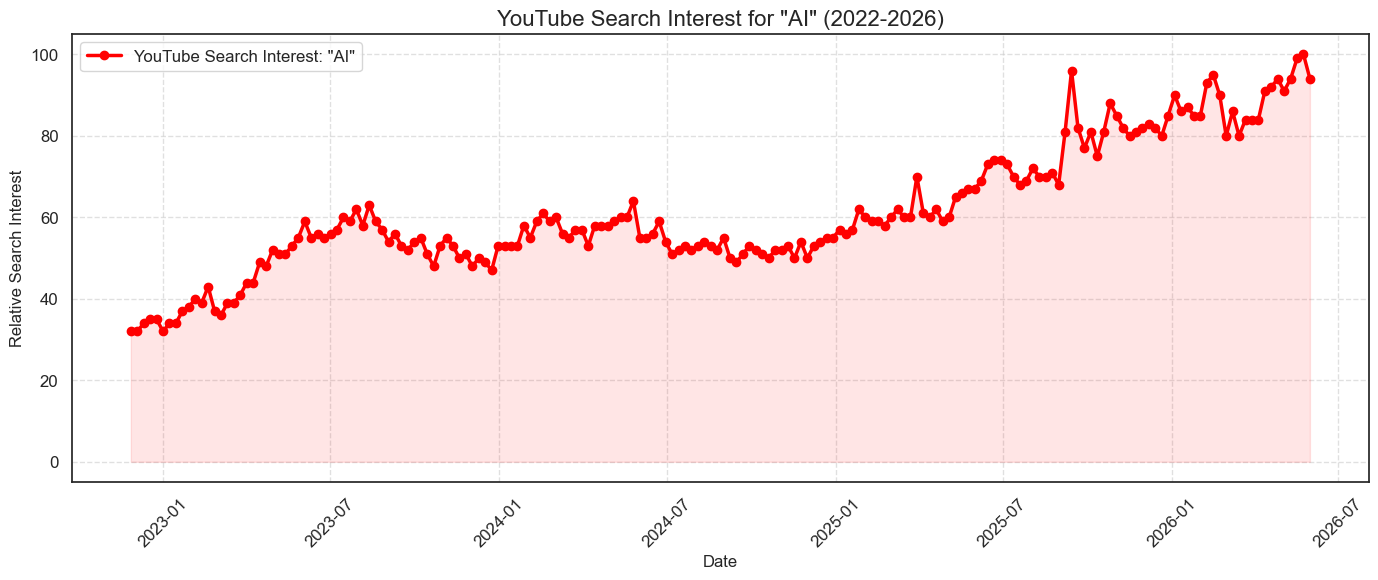

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot the search interest
plt.plot(
    youtube_trends_df.index, 
    youtube_trends_df[SEARCH_QUERY], 
    color='#FF0000', # YouTube Red
    linewidth=2.5,
    marker='o',
    label=f'YouTube Search Interest: "{SEARCH_QUERY}"'
)

# Fill the area under the line slightly for visual impact
plt.fill_between(
    youtube_trends_df.index, 
    youtube_trends_df[SEARCH_QUERY], 
    color='#FF0000', 
    alpha=0.1
)

plt.title(f'YouTube Search Interest for "{SEARCH_QUERY}" (2022-2026)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Search Interest', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()